# Combined Pokemon Project Notebook

This notebook combines the four project scripts into one ordered analysis workflow. It uses the cleaned Pokemon dataset once at the beginning, then reuses the same dataframe for dual-type analysis, type personality profiles, capture difficulty analysis, and legendary-classification modeling.


## Import packages

This section imports the packages used by all four project parts and defines shared constants and helper functions.


In [3]:
from pathlib import Path
from math import pi
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    classification_report,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 9

TYPE_COLORS = {
    "normal": "#A8A878", "fire": "#F08030", "water": "#6890F0",
    "electric": "#F8D030", "grass": "#78C850", "ice": "#98D8D8",
    "fighting": "#C03028", "poison": "#A040A0", "ground": "#E0C068",
    "flying": "#A890F0", "psychic": "#F85888", "bug": "#A8B820",
    "rock": "#B8A038", "ghost": "#705898", "dragon": "#7038F8",
    "dark": "#705848", "steel": "#B8B8D0", "fairy": "#EE99AC",
}

STAT_COLUMNS = ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]
PROFILE_LABELS = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
STAT_MAP = {
    "hp": "HP", "attack": "Atk", "defense": "Def",
    "sp_attack": "SpA", "sp_defense": "SpD", "speed": "Spe",
}

NUM_CATEGORIES = len(PROFILE_LABELS)
ANGLES = [n / NUM_CATEGORIES * 2 * pi for n in range(NUM_CATEGORIES)]
ANGLES += ANGLES[:1]


def normalize_type2(series):
    '''Convert missing or blank secondary-type values to the label "None".'''
    return (
        series.fillna("None")
        .astype(str)
        .str.strip()
        .replace({"": "None", "nan": "None", "NaN": "None"})
    )


def parse_capture_rate(value):
    '''Convert capture_rate values to numbers, using the minimum number when a cell contains multiple rates.'''
    if pd.isna(value):
        return np.nan

    numbers = re.findall(r"\d+", str(value).strip())
    if not numbers:
        return np.nan

    return min(int(number) for number in numbers)


def plot_radar_values(ax, values, color, label=None, linewidth=2.4, alpha=0.2):
    '''Plot one closed radar profile on an existing polar axis.'''
    closed_values = list(values) + list(values)[:1]
    line, = ax.plot(ANGLES, closed_values, linewidth=linewidth, color=color, label=label)
    ax.fill(ANGLES, closed_values, color=color, alpha=alpha)
    return line


## Load dataset

The notebook reads only the cleaned dataset from the project directory. All later parts reuse `df` instead of reading another CSV file.


In [4]:
DATA_PATH = Path("pokemon_cleaned.csv")
df = pd.read_csv(DATA_PATH)

print("Data file:", DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())


Data file: pokemon_cleaned.csv
Dataset shape: (801, 41)


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,49,5120,70,318,45,Seed Pokémon,49,1059860,0.7,45,Fushigidaneフシギダネ,Bulbasaur,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,62,5120,70,405,45,Seed Pokémon,63,1059860,1.0,60,Fushigisouフシギソウ,Ivysaur,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,100,5120,70,625,45,Seed Pokémon,123,1059860,2.0,80,Fushigibanaフシギバナ,Venusaur,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,2.0,0.5,1.0,1.0,1.0,2.0,0.5,2.0,52,5120,70,309,45,Lizard Pokémon,43,1059860,0.6,39,Hitokageヒトカゲ,Charmander,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,2.0,0.5,1.0,1.0,1.0,2.0,0.5,2.0,64,5120,70,405,45,Flame Pokémon,58,1059860,1.1,58,Lizardoリザード,Charmeleon,88.1,5,80,65,80,fire,NaN,19.0,1,0


## Dataset Exploration

This section provides basic dataset information, missing value analysis, and summary statistics before diving into detailed analysis.

In [5]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 6)

# ============================================================
# 1. Load the raw dataset
# ============================================================
print("=" * 60)
print("POKEMON DATASET - BASIC INTRODUCTION")
print("=" * 60)

# Note: Using the same dataset as other parts, but raw version
df_raw = pd.read_csv('pokemon.csv')
print(f"\nDataset loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

# ============================================================
# 2. Basic dataset information
# ============================================================
print("\n" + "=" * 60)
print("1. BASIC DATASET INFORMATION")
print("=" * 60)

print(f"\n- Total Pokemon: {df_raw.shape[0]}")
print(f"- Total Features (columns): {df_raw.shape[1]}")
print(f"- Generations covered: {df_raw['generation'].min()} to {df_raw['generation'].max()}")
print(f"- File size: ~{df_raw.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB in memory")

# ============================================================
# 3. Column categories (for slide table)
# ============================================================
print("\n" + "=" * 60)
print("2. COLUMN CATEGORIES")
print("=" * 60)

# Group columns by category
categories = {
    "Identification": ['name', 'japanese_name', 'pokedex_number', 'classification', 'generation'],
    "Type": ['type1', 'type2'],
    "Base Stats (6)": ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_total'],
    "Type Effectiveness (18)": [col for col in df_raw.columns if col.startswith('against_')],
    "Physical": ['height_m', 'weight_kg'],
    "Gender": ['percentage_male'],
    "Abilities": ['abilities'],
    "Other Game Data": ['capture_rate', 'base_egg_steps', 'base_happiness', 'experience_growth', 'is_legendary']
}

print("\n--- Column Breakdown ---")
for category, cols in categories.items():
    print(f"{category}: {len(cols)} columns")
    if len(cols) <= 6:
        print(f"  → {cols}")

# ============================================================
# 4. Missing values analysis (for bar chart)
# ============================================================
print("\n" + "=" * 60)
print("3. MISSING VALUES")
print("=" * 60)

missing_counts = df_raw.isnull().sum()
missing_percent = (missing_counts / len(df_raw)) * 100

# Only show columns with missing values
missing_data = pd.DataFrame({
    'Column': missing_counts[missing_counts > 0].index,
    'Missing': missing_counts[missing_counts > 0].values,
    'Percent': missing_percent[missing_percent > 0].values
})
missing_data = missing_data.sort_values('Missing', ascending=False)

print("\nColumns with missing values:")
print(missing_data.to_string(index=False))

POKEMON DATASET - BASIC INTRODUCTION

Dataset loaded: 801 rows, 41 columns

1. BASIC DATASET INFORMATION

- Total Pokemon: 801
- Total Features (columns): 41
- Generations covered: 1 to 7
- File size: ~0.61 MB in memory

2. COLUMN CATEGORIES

--- Column Breakdown ---
Identification: 5 columns
  → ['name', 'japanese_name', 'pokedex_number', 'classification', 'generation']
Type: 2 columns
  → ['type1', 'type2']
Base Stats (6): 7 columns
Type Effectiveness (18): 18 columns
Physical: 2 columns
  → ['height_m', 'weight_kg']
Gender: 1 columns
  → ['percentage_male']
Abilities: 1 columns
  → ['abilities']
Other Game Data: 5 columns
  → ['capture_rate', 'base_egg_steps', 'base_happiness', 'experience_growth', 'is_legendary']

3. MISSING VALUES

Columns with missing values:
         Column  Missing   Percent
          type2      384 47.940075
percentage_male       98 12.234707
       height_m       20  2.496879
      weight_kg       20  2.496879


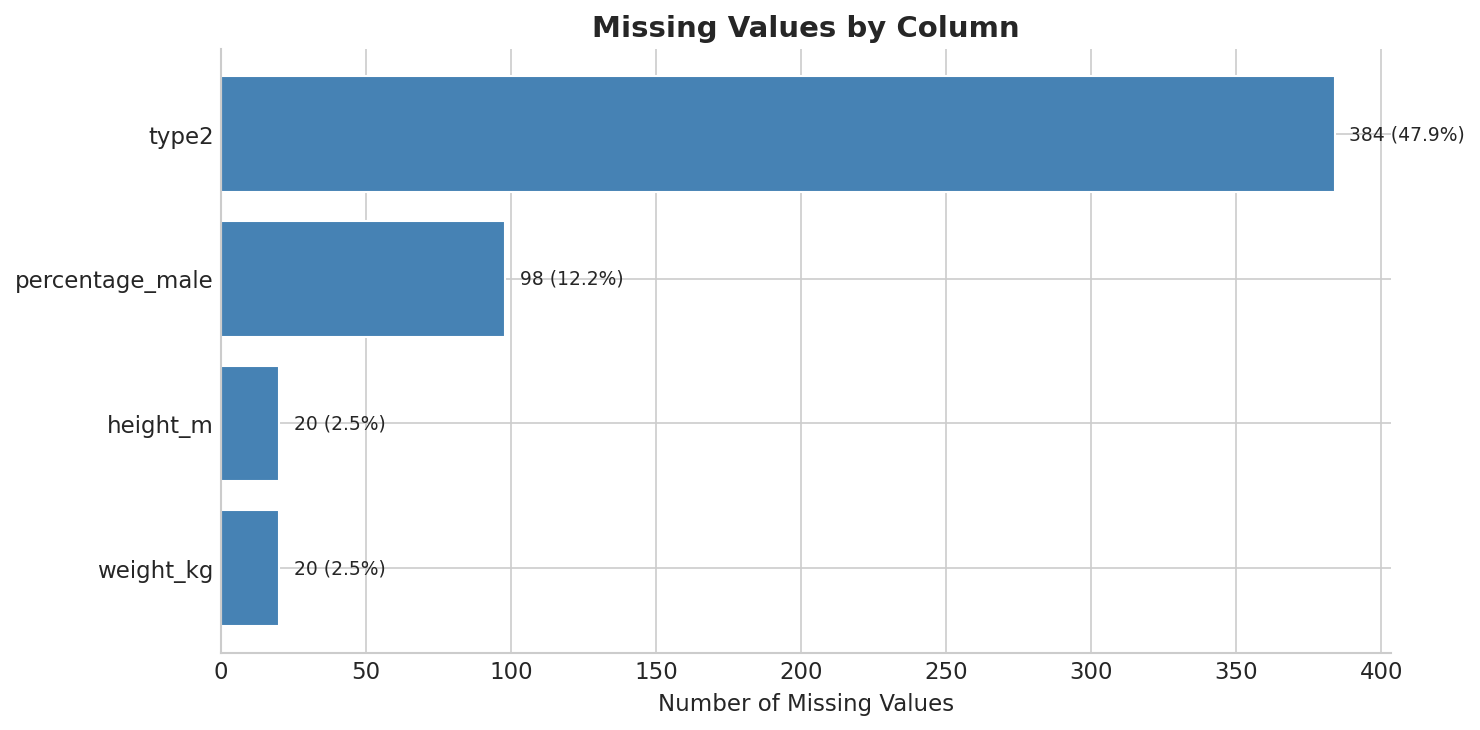

In [6]:
# Figure 1: Missing Values Bar Chart
fig1, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(missing_data['Column'], missing_data['Missing'], color='steelblue', edgecolor='white')

# Add value labels
for bar, row in zip(bars, missing_data.itertuples()):
    label = f"{int(row.Missing)} ({row.Percent:.1f}%)"
    ax.text(row.Missing + 5, bar.get_y() + bar.get_height()/2, 
            label, va='center', fontsize=9)

ax.set_xlabel('Number of Missing Values', fontsize=11)
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

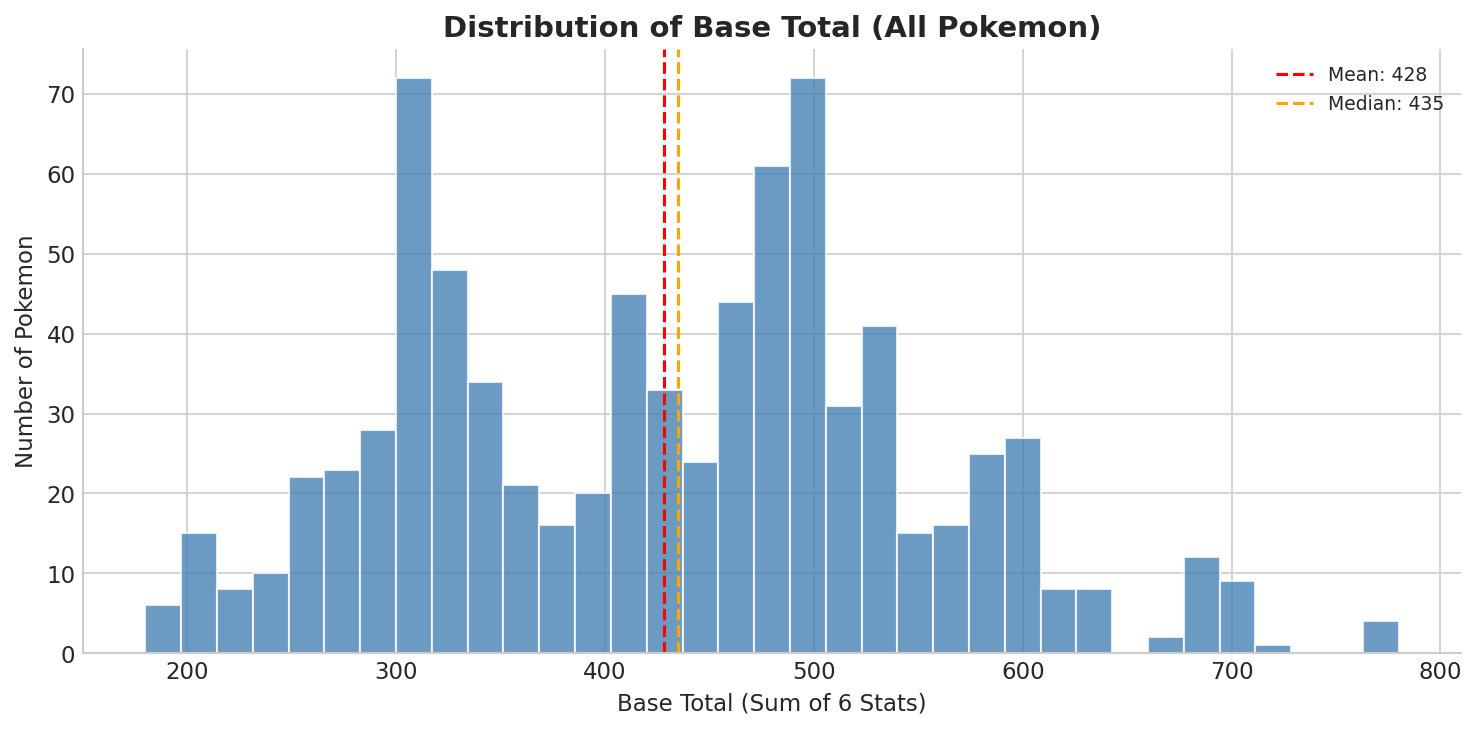

In [7]:
# Figure 2: Distribution of Base Total (overall)
fig2, ax = plt.subplots(figsize=(10, 5))

# Histogram of base_total
ax.hist(df_raw['base_total'], bins=35, color='steelblue', edgecolor='white', alpha=0.8)

# Add mean and median lines
mean_val = df_raw['base_total'].mean()
median_val = df_raw['base_total'].median()
ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.0f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.0f}')

ax.set_xlabel('Base Total (Sum of 6 Stats)', fontsize=11)
ax.set_ylabel('Number of Pokemon', fontsize=11)
ax.set_title('Distribution of Base Total (All Pokemon)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

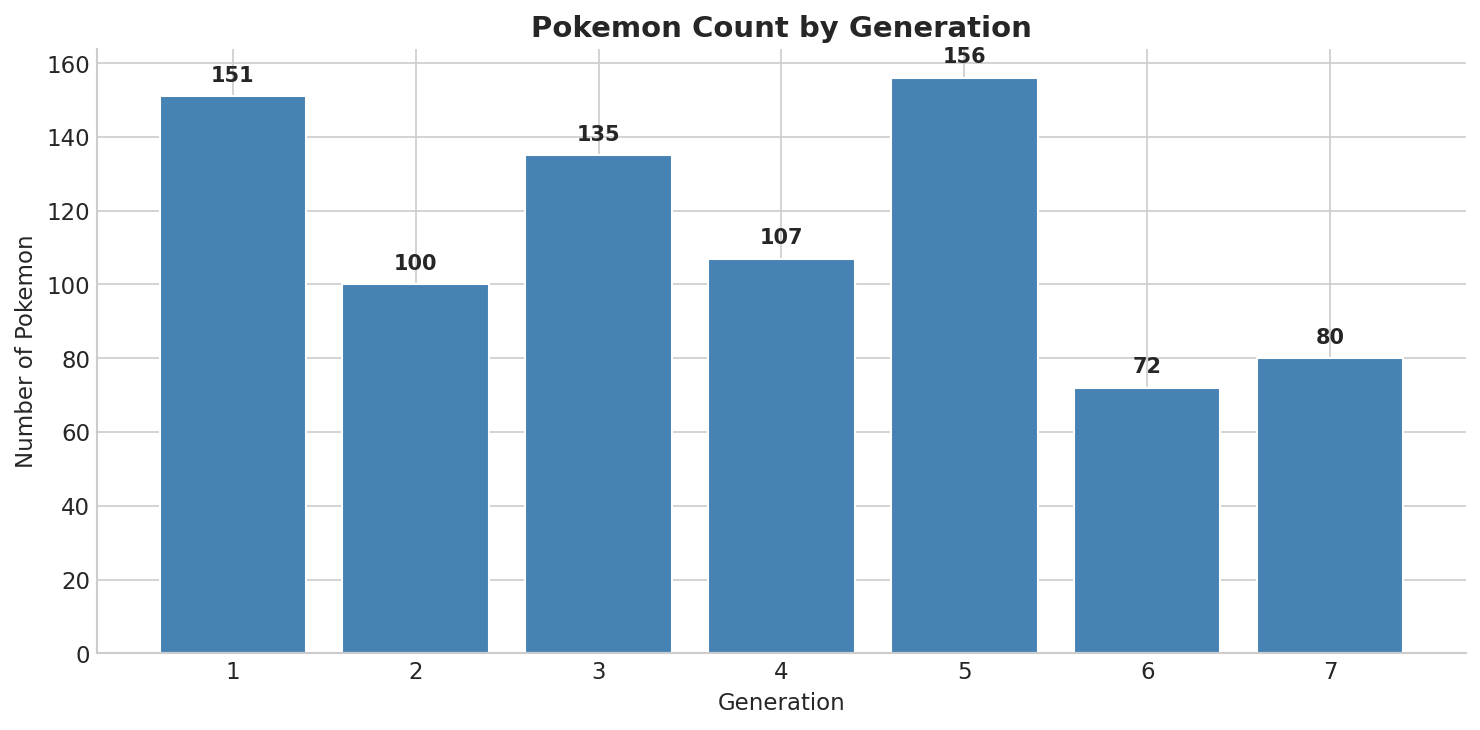

In [8]:
# Figure 3: Generation Distribution
gen_counts = df_raw['generation'].value_counts().sort_index()

fig3, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(gen_counts.index, gen_counts.values, color='steelblue', edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, gen_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Generation', fontsize=11)
ax.set_ylabel('Number of Pokemon', fontsize=11)
ax.set_title('Pokemon Count by Generation', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 8))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Data Cleaning

This section handles missing values in the dataset before proceeding with the analysis. The cleaning includes:
- Filling missing secondary types with 'None' (indicating single-type Pokemon)
- Imputing missing height and weight values using group-based median imputation by primary type

In [10]:
"""
Pokemon Dataset - Basic Data Cleaning
Handles missing values with group-based median imputation
"""

import pandas as pd

# ============================================================
# 1. Load the dataset
# ============================================================
print("=" * 60)
print("STEP 1: Loading the dataset")
print("=" * 60)

df = pd.read_csv('pokemon.csv')
print(f"Original dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# ============================================================
# 2. Handle missing values in 'type2'
# ============================================================
print("\n" + "=" * 60)
print("STEP 2: Handling missing values in 'type2'")
print("=" * 60)

missing_type2_before = df['type2'].isnull().sum()
print(f"Missing values in 'type2' before: {missing_type2_before}")

df['type2'] = df['type2'].fillna('None')

missing_type2_after = df['type2'].isnull().sum()
print(f"Missing values in 'type2' after: {missing_type2_after}")

# ============================================================
# 3. Handle missing values in 'height_m' and 'weight_kg'
#    using groupby median by 'type1'
# ============================================================
print("\n" + "=" * 60)
print("STEP 3: Handling missing values in 'height_m' and 'weight_kg'")
print("=" * 60)

# Check missing counts before
missing_height_before = df['height_m'].isnull().sum()
missing_weight_before = df['weight_kg'].isnull().sum()
print(f"Missing values in 'height_m' before: {missing_height_before}")
print(f"Missing values in 'weight_kg' before: {missing_weight_before}")

# Show which Pokemon have missing height/weight (for verification)
missing_mask = df['height_m'].isnull() | df['weight_kg'].isnull()
print(f"\nPokemon with missing height or weight: {missing_mask.sum()} rows")
print(df[missing_mask][['name', 'type1', 'type2', 'height_m', 'weight_kg']].head(10))

# Fill missing height_m with group median by type1
print("\n--- Filling 'height_m' with group median by type1 ---")
df['height_m'] = df.groupby('type1')['height_m'].transform(
    lambda x: x.fillna(x.median())
)

# Fill missing weight_kg with group median by type1
print("--- Filling 'weight_kg' with group median by type1 ---")
df['weight_kg'] = df.groupby('type1')['weight_kg'].transform(
    lambda x: x.fillna(x.median())
)

# Verify no missing values remain
missing_height_after = df['height_m'].isnull().sum()
missing_weight_after = df['weight_kg'].isnull().sum()
print(f"\nMissing values in 'height_m' after: {missing_height_after}")
print(f"Missing values in 'weight_kg' after: {missing_weight_after}")

# Check if any group had no valid values (all NaN) - then median would be NaN
if missing_height_after > 0 or missing_weight_after > 0:
    print("\nWARNING: Some type groups may have all missing values.")
    print("Falling back to global median for remaining missing values.")
    
    # Fallback: use global median for any remaining missing
    global_median_height = df['height_m'].median()
    global_median_weight = df['weight_kg'].median()
    df['height_m'] = df['height_m'].fillna(global_median_height)
    df['weight_kg'] = df['weight_kg'].fillna(global_median_weight)
    
    print(f"Global median height used as fallback: {global_median_height}")
    print(f"Global median weight used as fallback: {global_median_weight}")

# ============================================================
# 4. Save the cleaned dataset
# ============================================================
print("\n" + "=" * 60)
print("STEP 4: Saving cleaned dataset")
print("=" * 60)

df.to_csv('pokemon_cleaned.csv', index=False)
print(f"Cleaned dataset saved as: pokemon_cleaned.csv")
print(f"Final dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# ============================================================
# 5. Summary
# ============================================================
print("\n" + "=" * 60)
print("CLEANING SUMMARY")
print("=" * 60)
print("Operations performed:")
print("  1. type2: filled missing values with 'None' (single-type Pokemon)")
print("  2. percentage_male: kept as is (NaN = genderless Pokemon)")
print("  3. height_m: filled missing values with group median by type1")
print("  4. weight_kg: filled missing values with group median by type1")
print("\n Basic data cleaning completed successfully!")

STEP 1: Loading the dataset
Original dataset shape: 801 rows, 41 columns

STEP 2: Handling missing values in 'type2'
Missing values in 'type2' before: 384
Missing values in 'type2' after: 0

STEP 3: Handling missing values in 'height_m' and 'weight_kg'
Missing values in 'height_m' before: 20
Missing values in 'weight_kg' before: 20

Pokemon with missing height or weight: 20 rows
         name     type1     type2  height_m  weight_kg
18    Rattata    normal      dark       NaN        NaN
19   Raticate    normal      dark       NaN        NaN
25     Raichu  electric  electric       NaN        NaN
26  Sandshrew    ground       ice       NaN        NaN
27  Sandslash    ground       ice       NaN        NaN
36     Vulpix      fire       ice       NaN        NaN
37  Ninetales      fire       ice       NaN        NaN
49    Diglett    ground    ground       NaN        NaN
50    Dugtrio    ground    ground       NaN        NaN
51     Meowth    normal      dark       NaN        NaN

--- Filling 

## Part1 Analysis of Pokémon dual types

This section studies Pokemon dual-type combinations. It calculates combination frequency, average base stat total, power tiers, and legendary ratios for each type pairing.


In [3]:
dual_df = df.copy()
dual_df["type1"] = dual_df["type1"].astype(str).str.strip()
dual_df["type2_cleaned"] = normalize_type2(dual_df["type2"])

dual_df["dual_type"] = np.where(
    dual_df["type2_cleaned"].ne("None"),
    dual_df["type1"] + " + " + dual_df["type2_cleaned"],
    dual_df["type1"] + " (Single Type)",
)

dual_type_stats = (
    dual_df.groupby("dual_type")
    .agg(
        count=("name", "count"),
        legendary_count=("is_legendary", "sum"),
        avg_bst=("base_total", "mean"),
        avg_hp=("hp", "mean"),
        avg_attack=("attack", "mean"),
        avg_defense=("defense", "mean"),
        avg_sp_attack=("sp_attack", "mean"),
        avg_sp_defense=("sp_defense", "mean"),
        avg_speed=("speed", "mean"),
    )
    .reset_index()
)

dual_type_stats["legendary_ratio"] = dual_type_stats["legendary_count"] / dual_type_stats["count"]


def assign_tier(avg_bst):
    if avg_bst >= 600:
        return "T0 (Top Tier)"
    if avg_bst >= 550:
        return "T1 (Strong Tier)"
    if avg_bst >= 500:
        return "T2 (Mid Tier)"
    return "T3 (Basic Tier)"


dual_type_stats["tier"] = dual_type_stats["avg_bst"].apply(assign_tier)

all_types = list(TYPE_COLORS.keys())
frequency_matrix = pd.DataFrame(0, index=all_types, columns=all_types)

for _, row in dual_df.loc[dual_df["type2_cleaned"].ne("None")].iterrows():
    primary_type = row["type1"]
    secondary_type = row["type2_cleaned"]
    if primary_type in frequency_matrix.index and secondary_type in frequency_matrix.columns:
        frequency_matrix.loc[primary_type, secondary_type] += 1

true_dual_stats = dual_type_stats.loc[~dual_type_stats["dual_type"].str.contains("Single Type", regex=False)].copy()
tier_order = ["T0 (Top Tier)", "T1 (Strong Tier)", "T2 (Mid Tier)", "T3 (Basic Tier)"]
tier_counts = true_dual_stats["tier"].value_counts().reindex(tier_order, fill_value=0)
legendary_dual = (
    true_dual_stats.loc[true_dual_stats["legendary_count"] > 0]
    .sort_values("legendary_ratio", ascending=False)
)

print("Unique true dual-type combinations:", len(true_dual_stats))
display(dual_type_stats.sort_values("avg_bst", ascending=False).head(10))


NameError: name 'df' is not defined

### Figure 1.1: Dual Type Combination Frequency


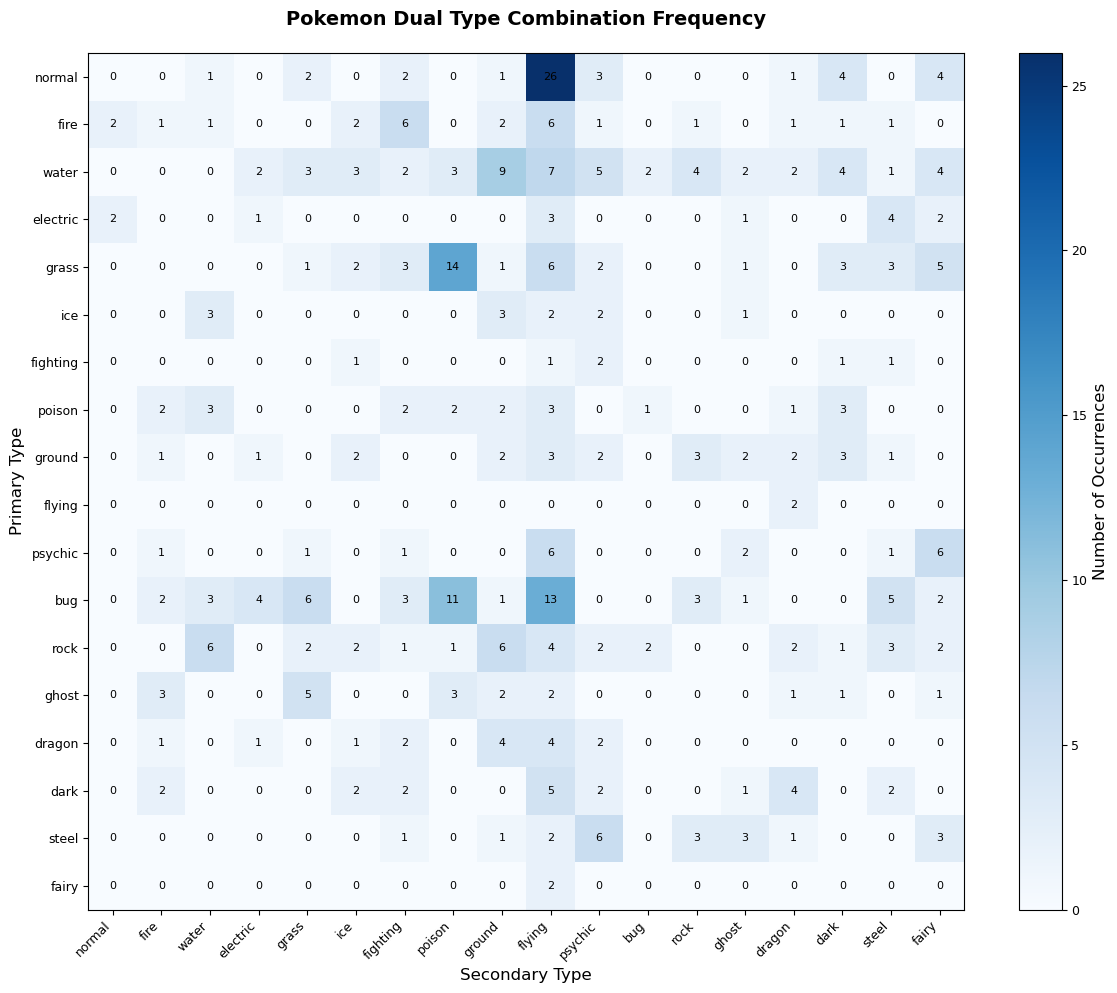

In [4]:
plt.figure(figsize=(12, 10))
im = plt.imshow(frequency_matrix, cmap="Blues", aspect="auto")

plt.xticks(range(len(frequency_matrix.columns)), frequency_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(frequency_matrix.index)), frequency_matrix.index)

for i in range(len(frequency_matrix.index)):
    for j in range(len(frequency_matrix.columns)):
        plt.text(j, i, str(frequency_matrix.iloc[i, j]), ha="center", va="center", fontsize=8)

cbar = plt.colorbar(im)
cbar.set_label("Number of Occurrences", fontsize=12)

plt.title("Pokemon Dual Type Combination Frequency", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Secondary Type", fontsize=12)
plt.ylabel("Primary Type", fontsize=12)
plt.tight_layout()
plt.show()
plt.close()


This code counts how often each primary-secondary type pair appears and visualizes the result as a heatmap. The figure shows which dual-type combinations are common and which combinations are rare or absent.


### Figure 1.2: Top 15 Strongest Dual Type Combinations


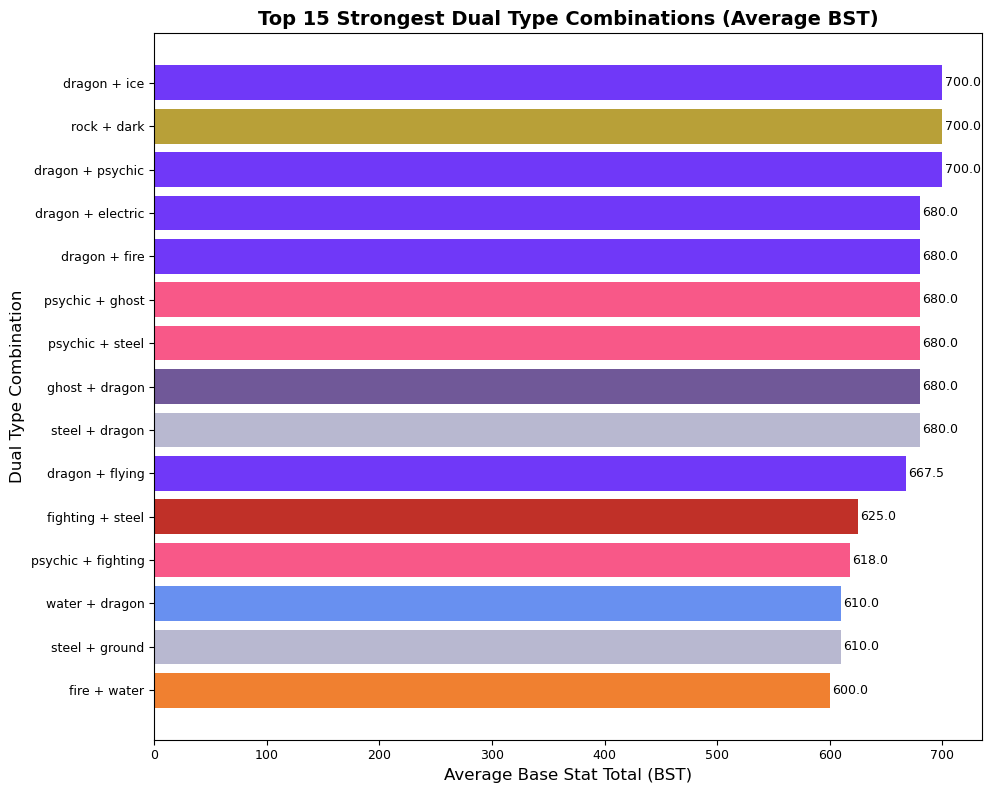

In [5]:
top15_strongest = true_dual_stats.sort_values("avg_bst", ascending=False).head(15)
colors = [TYPE_COLORS.get(type_name.split(" + ")[0], "#808080") for type_name in top15_strongest["dual_type"]]

plt.figure(figsize=(10, 8))
bars = plt.barh(top15_strongest["dual_type"], top15_strongest["avg_bst"], color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height() / 2, f"{width:.1f}", va="center", fontsize=9)

plt.title("Top 15 Strongest Dual Type Combinations (Average BST)", fontsize=14, fontweight="bold")
plt.xlabel("Average Base Stat Total (BST)", fontsize=12)
plt.ylabel("Dual Type Combination", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
plt.close()


This code ranks true dual-type combinations by average base stat total. The chart highlights which type pairings tend to have the strongest overall stat profiles.


### Figure 1.3: Ability Profiles of Popular Dual Types


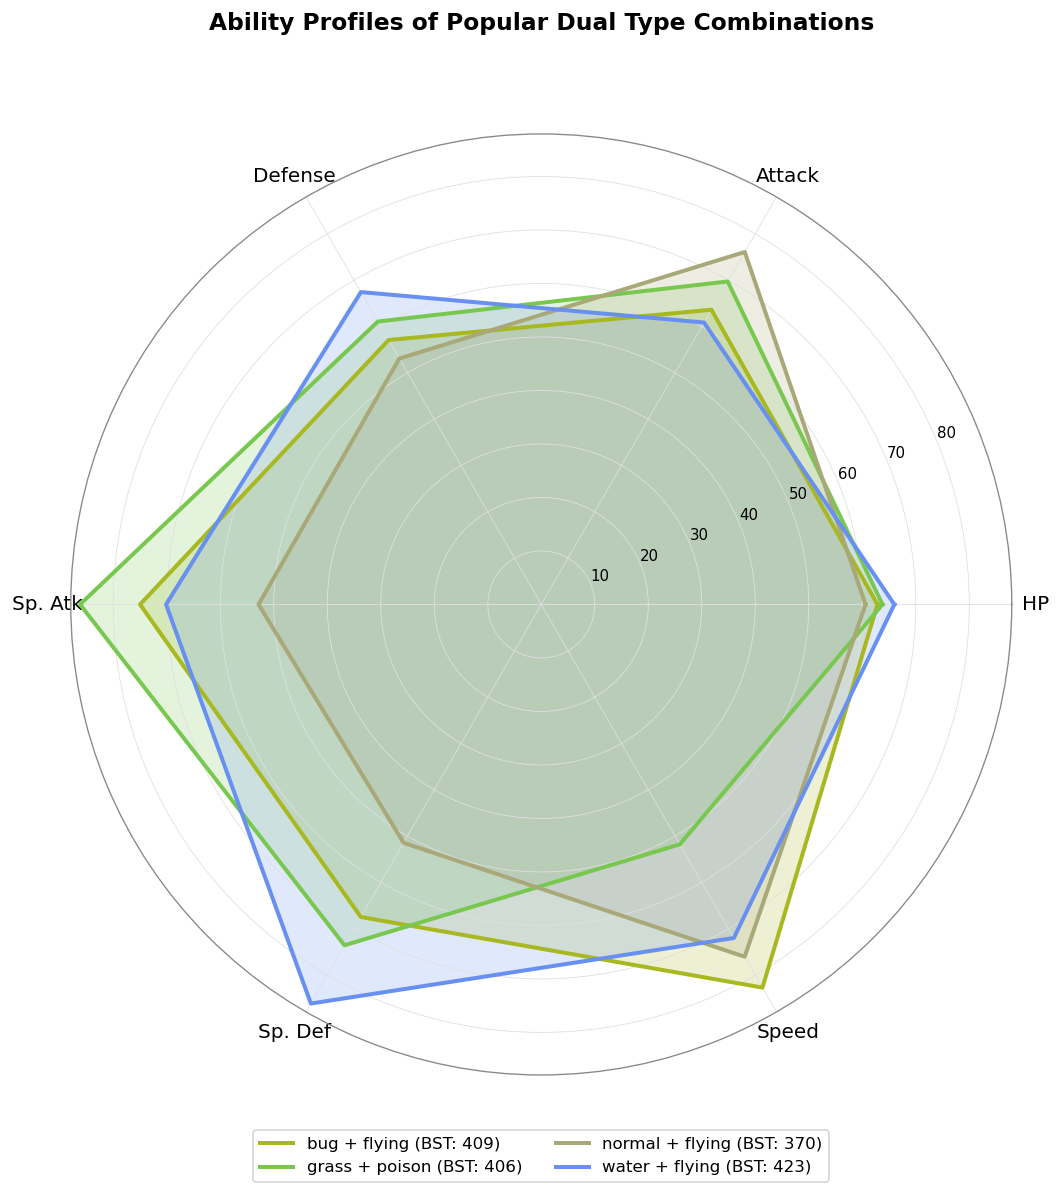

In [6]:
popular_combinations = ["normal + flying", "bug + flying", "grass + poison", "water + flying"]
popular_stats = true_dual_stats.loc[true_dual_stats["dual_type"].isin(popular_combinations)]

plt.figure(figsize=(10, 10), dpi=120)
ax = plt.subplot(111, polar=True)

for _, row in popular_stats.iterrows():
    dual_type = row["dual_type"]
    primary_type = dual_type.split(" + ")[0]
    values = [
        row["avg_hp"], row["avg_attack"], row["avg_defense"],
        row["avg_sp_attack"], row["avg_sp_defense"], row["avg_speed"],
    ]
    plot_radar_values(ax, values, TYPE_COLORS.get(primary_type, "#808080"), label=f"{dual_type} (BST: {row['avg_bst']:.0f})")

ax.set_xticks(ANGLES[:-1])
ax.set_xticklabels(PROFILE_LABELS, fontsize=12, fontweight="medium")
ax.grid(color="#e0e0e0", linestyle="-", linewidth=0.5)
ax.spines["polar"].set_color("#888888")

plt.title("Ability Profiles of Popular Dual Type Combinations", fontsize=14, fontweight="bold", y=1.1)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), fontsize=10, ncol=2)
plt.tight_layout()
plt.show()
plt.close()


This code compares average HP, Attack, Defense, Special Attack, Special Defense, and Speed for several common dual-type combinations. The radar chart shows how each pairing has a different stat personality.


### Figure 1.4: Dual Type Power Tier Distribution


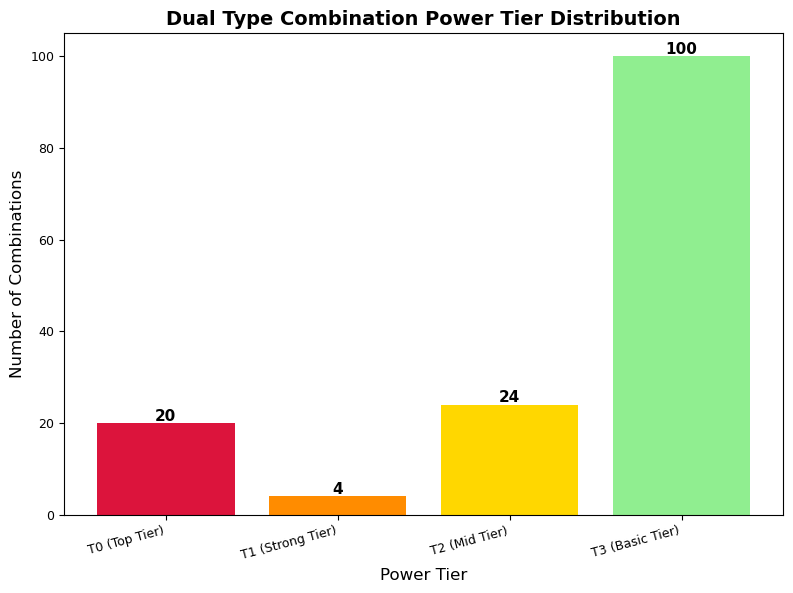

In [7]:
tier_colors = ["#DC143C", "#FF8C00", "#FFD700", "#90EE90"]

plt.figure(figsize=(8, 6))
bars = plt.bar(tier_counts.index, tier_counts.values, color=tier_colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, int(height), ha="center", fontsize=11, fontweight="bold")

plt.title("Dual Type Combination Power Tier Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Power Tier", fontsize=12)
plt.ylabel("Number of Combinations", fontsize=12)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()
plt.close()


This code groups dual-type combinations into tiers based on their average base stat total. The chart shows whether most combinations are concentrated in basic, mid, strong, or top-tier ranges.


### Figure 1.5: Top 10 Dual Types by Legendary Ratio


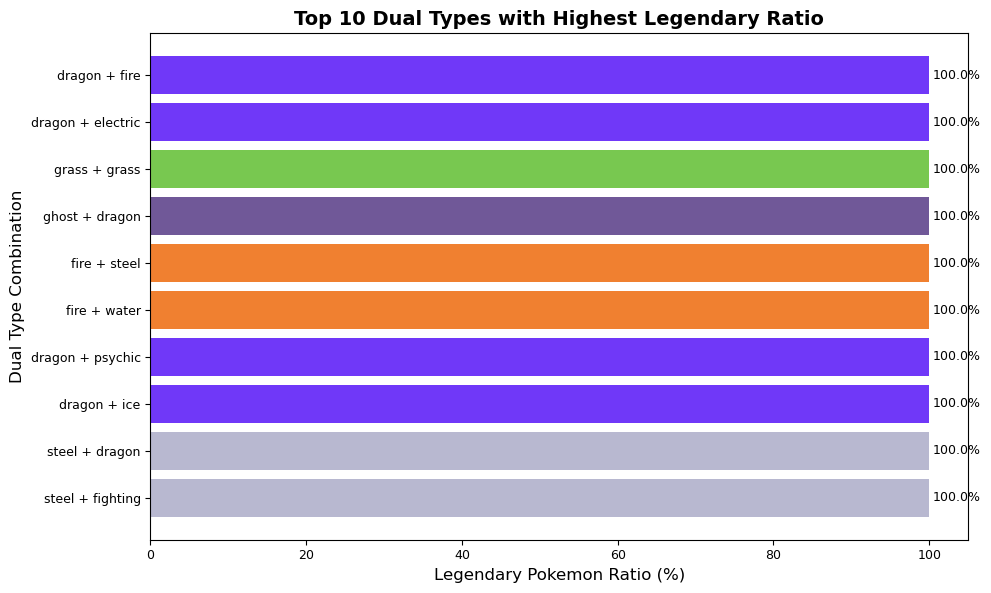

In [8]:
top10_legendary_dual = legendary_dual.head(10)
colors = [TYPE_COLORS.get(type_name.split(" + ")[0], "#808080") for type_name in top10_legendary_dual["dual_type"]]

plt.figure(figsize=(10, 6))
bars = plt.barh(top10_legendary_dual["dual_type"], top10_legendary_dual["legendary_ratio"] * 100, color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height() / 2, f"{width:.1f}%", va="center", fontsize=9)

plt.title("Top 10 Dual Types with Highest Legendary Ratio", fontsize=14, fontweight="bold")
plt.xlabel("Legendary Pokemon Ratio (%)", fontsize=12)
plt.ylabel("Dual Type Combination", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
plt.close()


This code finds dual-type combinations that include at least one legendary Pokemon and ranks them by legendary ratio. The chart identifies pairings where legendary Pokemon are especially common within the dataset.


## Part2 Analysis of Pokémon Personality Profiles

This section uses the updated type-profile logic from `pokemon_project(1).py`. It compares each type against the global average battle-stat profile, then summarizes type strength using average base stat total.


In [9]:
profile_stats = ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]
profile_df = df[["type1", "type2"] + profile_stats].dropna(subset=profile_stats).copy()
profile_df.columns = ["primary_type", "secondary_type"] + profile_stats
profile_df["primary_type"] = profile_df["primary_type"].astype(str).str.strip()
profile_df["secondary_type"] = normalize_type2(profile_df["secondary_type"])

global_means = profile_df[profile_stats].mean()
primary_profiles = profile_df[["primary_type"] + profile_stats].rename(columns={"primary_type": "type"})
secondary_profiles = profile_df.loc[
    profile_df["secondary_type"].ne("None"), ["secondary_type"] + profile_stats
].rename(columns={"secondary_type": "type"})

type_long = pd.concat([primary_profiles, secondary_profiles], ignore_index=True)
type_means = type_long.groupby("type")[profile_stats].mean()
type_deviations = type_means - global_means

profile_rows = []
for type_name in type_deviations.index:
    type_entries = type_long.loc[type_long["type"] == type_name]
    average_bst = type_entries[profile_stats].sum(axis=1).mean()
    total_entries = len(type_entries)
    primary_count = int((profile_df["primary_type"] == type_name).sum())
    profile_rows.append({
        "type": type_name,
        "average_bst": round(average_bst, 1),
        "total_entries": total_entries,
        "primary_count": primary_count,
        "secondary_count": total_entries - primary_count,
    })

full_stats_df = pd.DataFrame(profile_rows)
full_stats_df["secondary_ratio"] = full_stats_df["secondary_count"] / full_stats_df["total_entries"]
selected_types = [type_name for type_name in TYPE_COLORS if type_name in type_deviations.index]

best_type = full_stats_df.loc[full_stats_df["average_bst"].idxmax()]
worst_type = full_stats_df.loc[full_stats_df["average_bst"].idxmin()]
print(f"Highest average BST: {best_type['type']} ({best_type['average_bst']:.0f})")
print(f"Lowest average BST: {worst_type['type']} ({worst_type['average_bst']:.0f})")
display(full_stats_df.sort_values("average_bst", ascending=False).head(10))


Highest average BST: dragon (513)
Lowest average BST: bug (380)


,type,average_bst,total_entries,primary_count,secondary_count,secondary_ratio
2,dragon,513.0,44,27,17,0.386364
16,steel,493.7,46,24,22,0.478261
14,psychic,463.8,82,53,29,0.353659
5,fighting,456.6,53,28,25,0.471698
6,fire,453.6,65,52,13,0.200000
1,dark,447.7,50,29,21,0.420000
11,ice,447.1,38,23,15,0.394737
15,rock,447.0,59,45,14,0.237288
8,ghost,444.8,41,27,14,0.341463
7,flying,441.7,98,3,95,0.969388


In [10]:
def plot_updated_type_profile(type_name):
    if type_name not in type_deviations.index:
        raise ValueError(f"Unknown type: {type_name}")

    deviations = type_deviations.loc[type_name]
    color = TYPE_COLORS.get(type_name, "#888888")
    max_stat = deviations.idxmax()
    min_stat = deviations.idxmin()
    max_value = deviations.max()
    min_value = deviations.min()
    sign_max = "+" if max_value >= 0 else ""
    sign_min = "+" if min_value >= 0 else ""

    plt.figure(figsize=(7, 7), dpi=110)
    ax = plt.subplot(111, polar=True)
    plot_radar_values(ax, deviations, color, linewidth=3.0, alpha=0.25)
    ax.plot(ANGLES, [0] * len(ANGLES), "--", color="#888888", linewidth=1.2, label="Global Average")

    ax.set_xticks(ANGLES[:-1])
    ax.set_xticklabels(PROFILE_LABELS, fontsize=11)
    ax.set_title(
        f"{type_name.capitalize()} Type\n"
        f"Strongest: {STAT_MAP[max_stat]}{sign_max}{max_value:.1f} | "
        f"Weakest: {STAT_MAP[min_stat]}{sign_min}{min_value:.1f}",
        color=color,
        fontweight="bold",
        fontsize=13,
        pad=20,
    )
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), fontsize=10)
    ax.grid(color="#e0e0e0", linewidth=0.6)
    plt.tight_layout()
    plt.show()
    plt.close()


### Figure 2.1: All 18 Pokémon Types Radar Profile


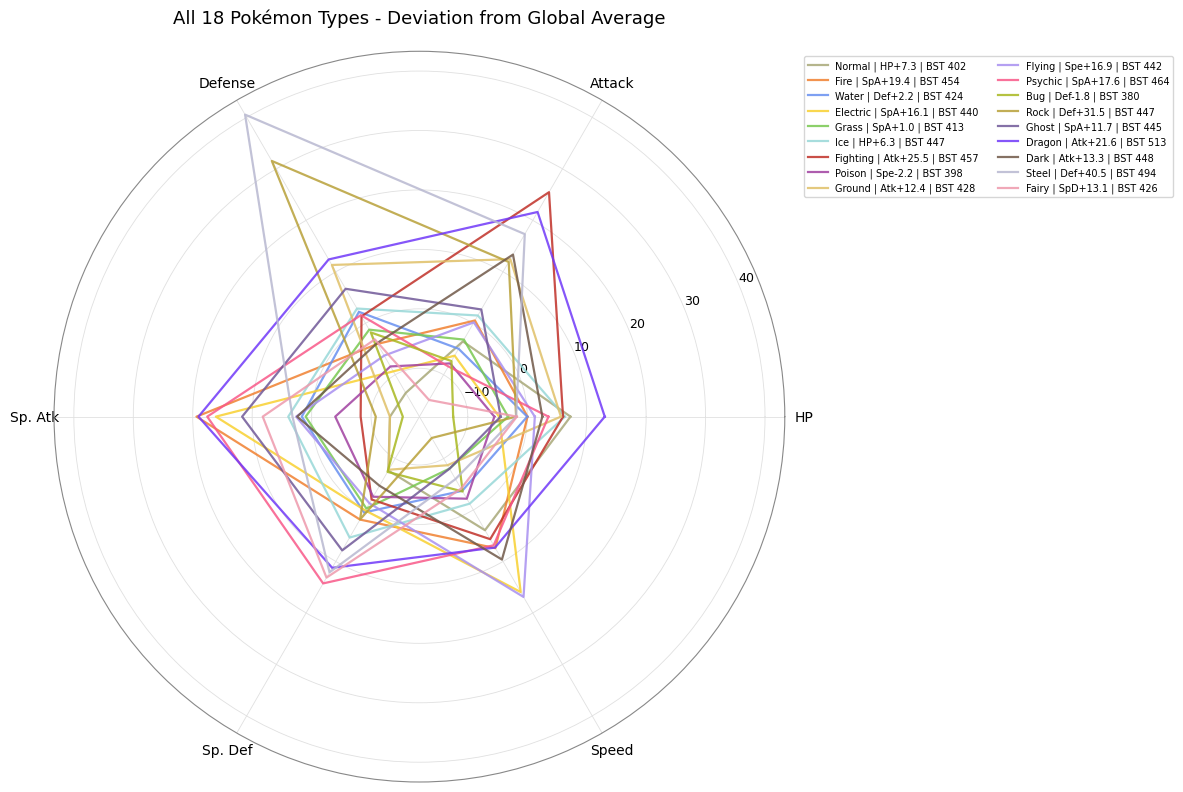

In [11]:
plt.figure(figsize=(12, 8), dpi=100)
ax = plt.subplot(111, polar=True)

for type_name in selected_types:
    deviations = type_deviations.loc[type_name]
    stats_row = full_stats_df.loc[full_stats_df["type"] == type_name].iloc[0]
    max_stat = deviations.idxmax()
    max_value = deviations.max()
    sign = "+" if max_value >= 0 else ""
    label = f"{type_name.capitalize()} | {STAT_MAP[max_stat]}{sign}{max_value:.1f} | BST {stats_row['average_bst']:.0f}"
    closed_values = deviations.tolist() + deviations.tolist()[:1]
    ax.plot(ANGLES, closed_values, color=TYPE_COLORS.get(type_name, "#888888"), linewidth=1.6, alpha=0.85, label=label)

ax.set_xticks(ANGLES[:-1])
ax.set_xticklabels(PROFILE_LABELS, fontsize=10)
ax.set_title("All 18 Pokémon Types - Deviation from Global Average", fontsize=13, pad=20)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=7, ncol=2)
ax.grid(color="#e0e0e0", linewidth=0.6)
ax.spines["polar"].set_color("#888888")
plt.tight_layout()
plt.show()
plt.close()


This code plots the updated all-type radar profile from `pokemon_project(1).py`. The figure compares how each Pokemon type deviates from the global average across HP, Attack, Defense, Special Attack, Special Defense, and Speed.


### Figure 2.2: Average Base Stat Total by Type


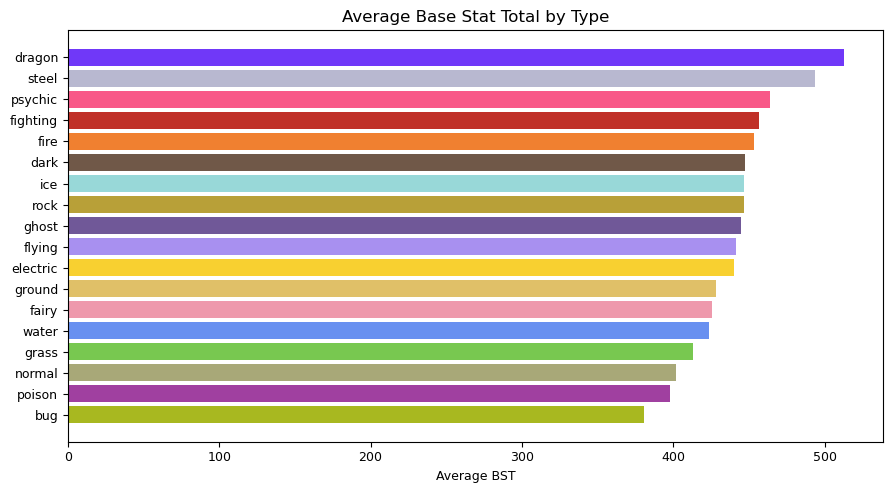

In [12]:
sorted_bst = full_stats_df.sort_values("average_bst", ascending=True)
colors = [TYPE_COLORS.get(type_name, "#888888") for type_name in sorted_bst["type"]]

plt.figure(figsize=(9, 5), dpi=100)
plt.barh(sorted_bst["type"], sorted_bst["average_bst"], color=colors)
plt.xlabel("Average BST")
plt.title("Average Base Stat Total by Type", fontsize=12)
plt.tight_layout()
plt.show()
plt.close()


This code ranks Pokemon types by average base stat total while counting both primary and secondary type appearances. The chart shows which types tend to have stronger overall stat totals.


### Figure 2.3: Normal Type Profile


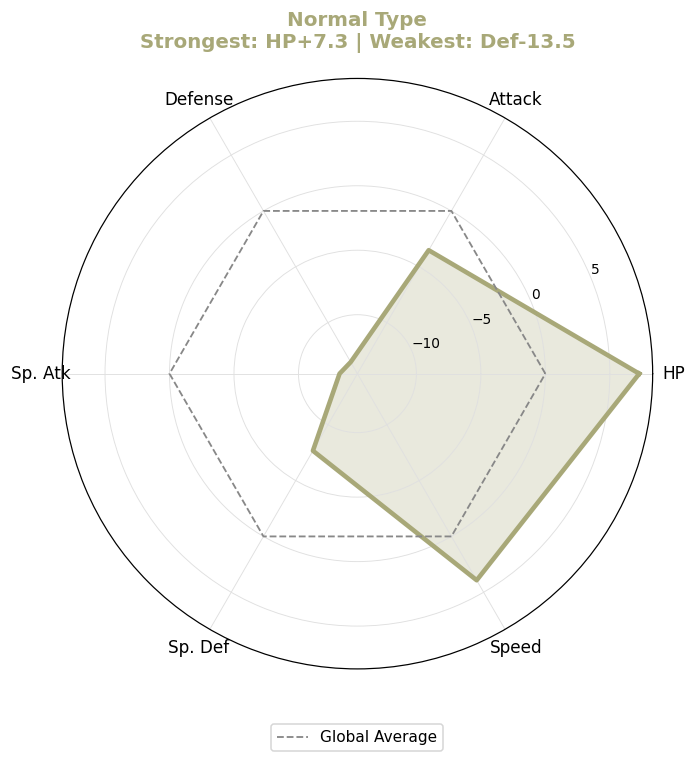

In [13]:
plot_updated_type_profile("normal")


This code draws the updated Normal type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.4: Fire Type Profile


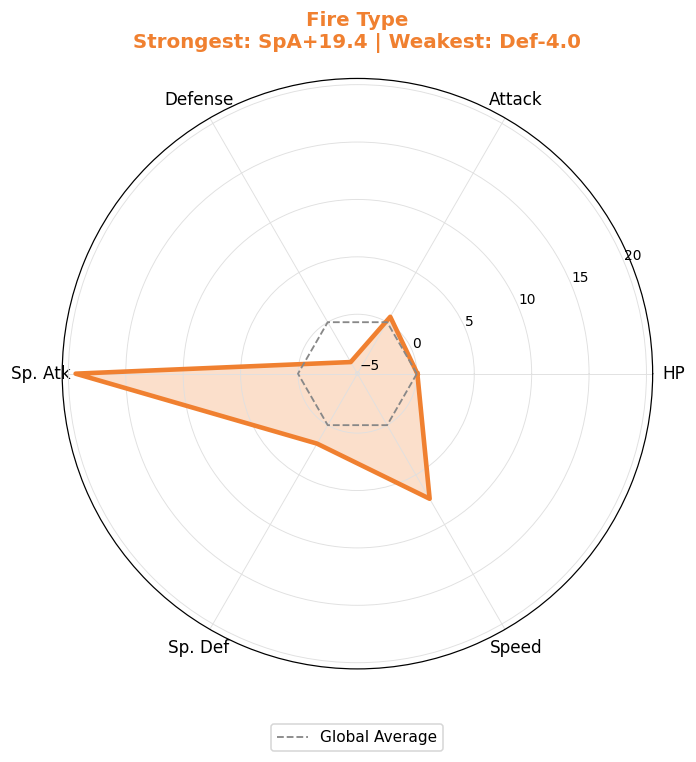

In [14]:
plot_updated_type_profile("fire")


This code draws the updated Fire type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.5: Water Type Profile


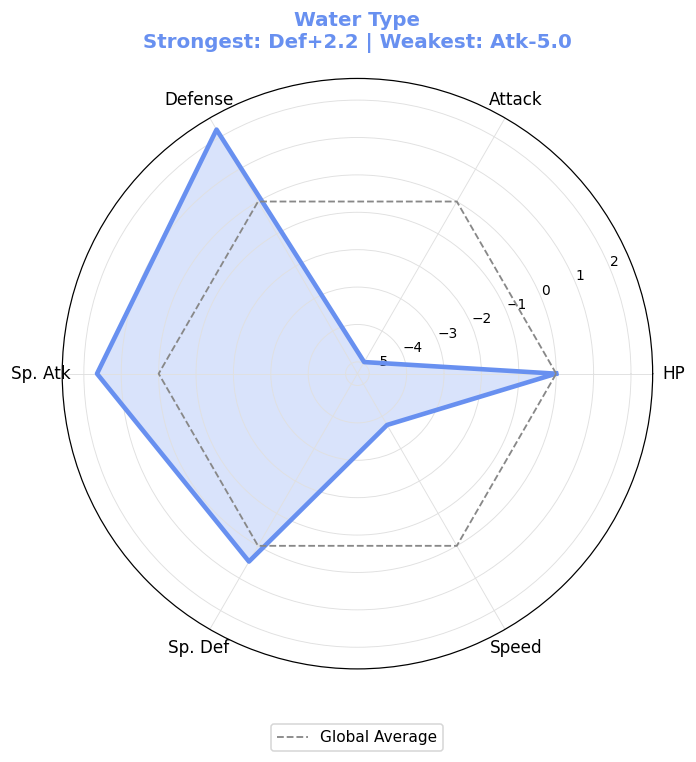

In [15]:
plot_updated_type_profile("water")


This code draws the updated Water type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.6: Electric Type Profile


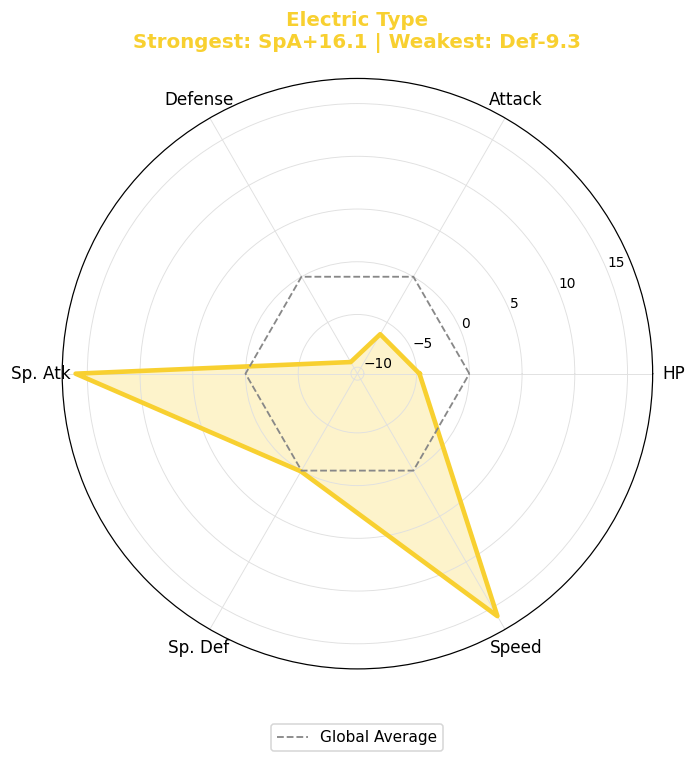

In [16]:
plot_updated_type_profile("electric")


This code draws the updated Electric type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.7: Grass Type Profile


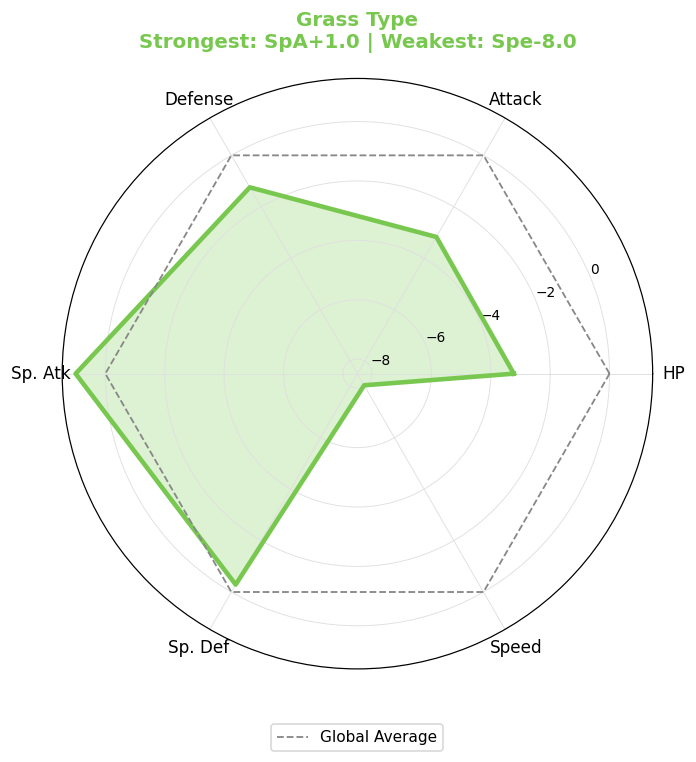

In [17]:
plot_updated_type_profile("grass")


This code draws the updated Grass type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.8: Ice Type Profile


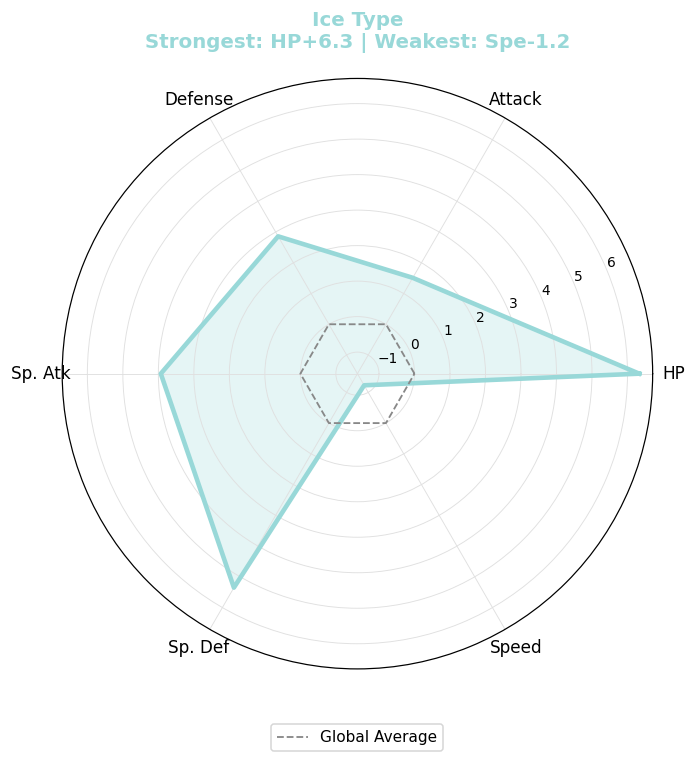

In [18]:
plot_updated_type_profile("ice")


This code draws the updated Ice type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.9: Fighting Type Profile


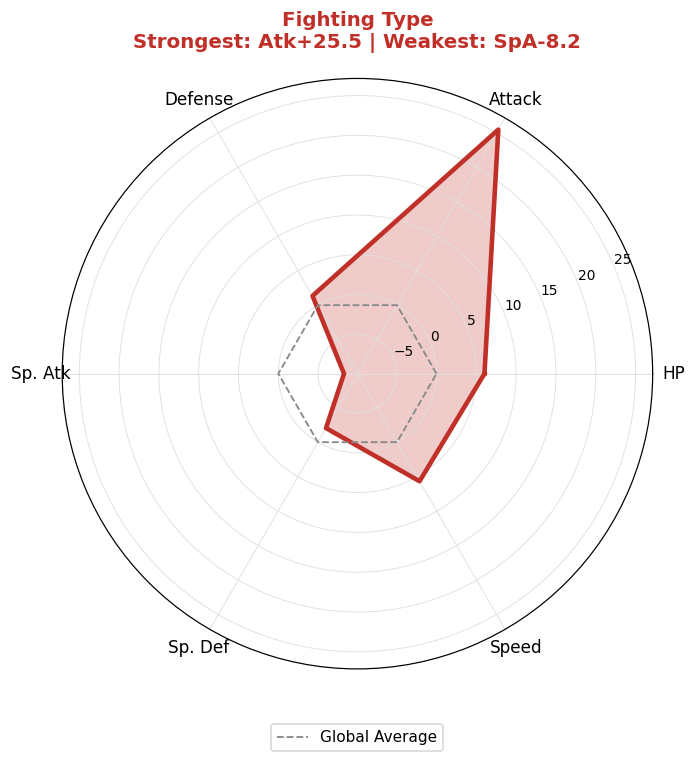

In [19]:
plot_updated_type_profile("fighting")


This code draws the updated Fighting type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.10: Poison Type Profile


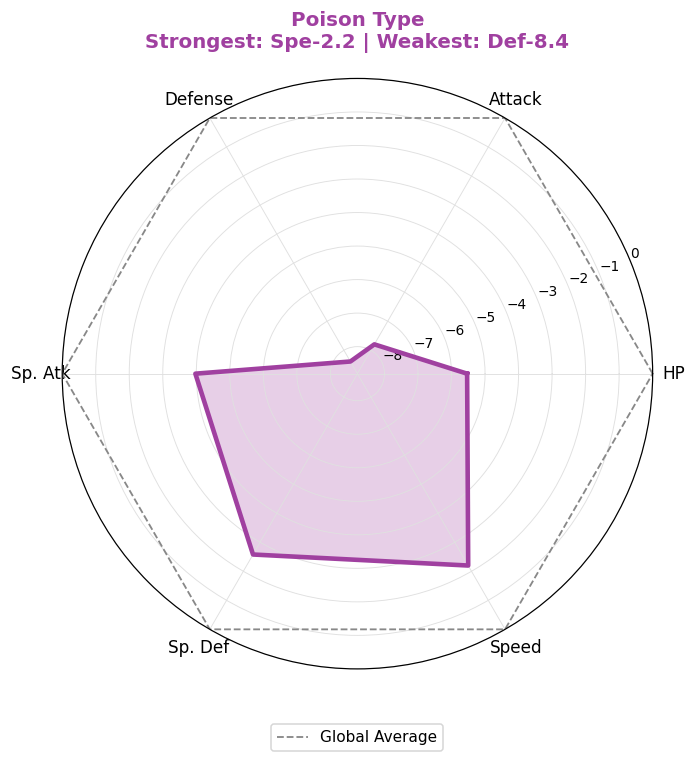

In [20]:
plot_updated_type_profile("poison")


This code draws the updated Poison type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.11: Ground Type Profile


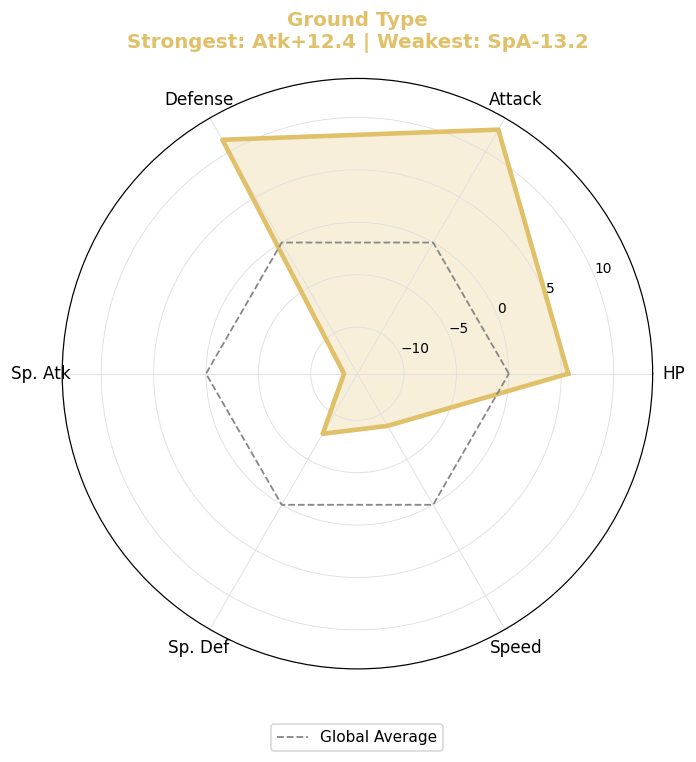

In [21]:
plot_updated_type_profile("ground")


This code draws the updated Ground type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.12: Flying Type Profile


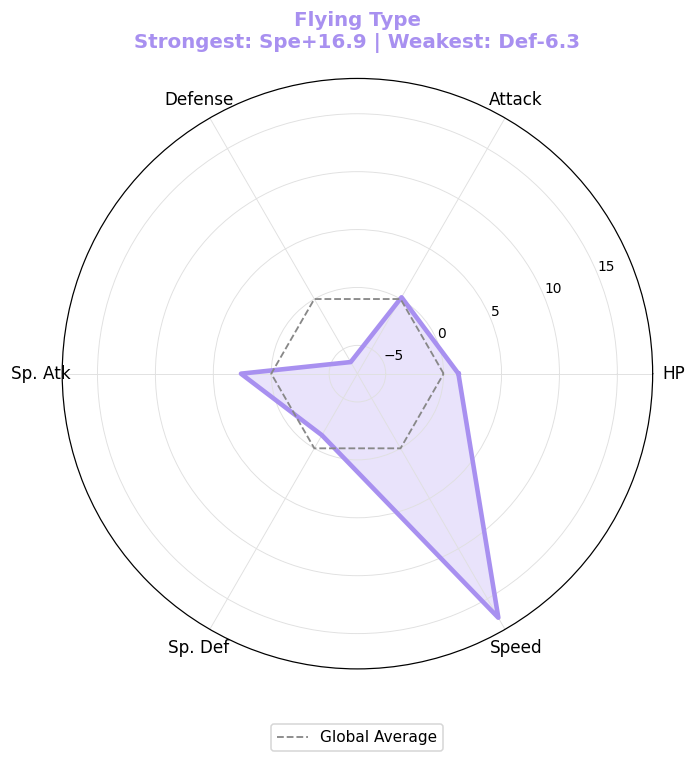

In [22]:
plot_updated_type_profile("flying")


This code draws the updated Flying type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.13: Psychic Type Profile


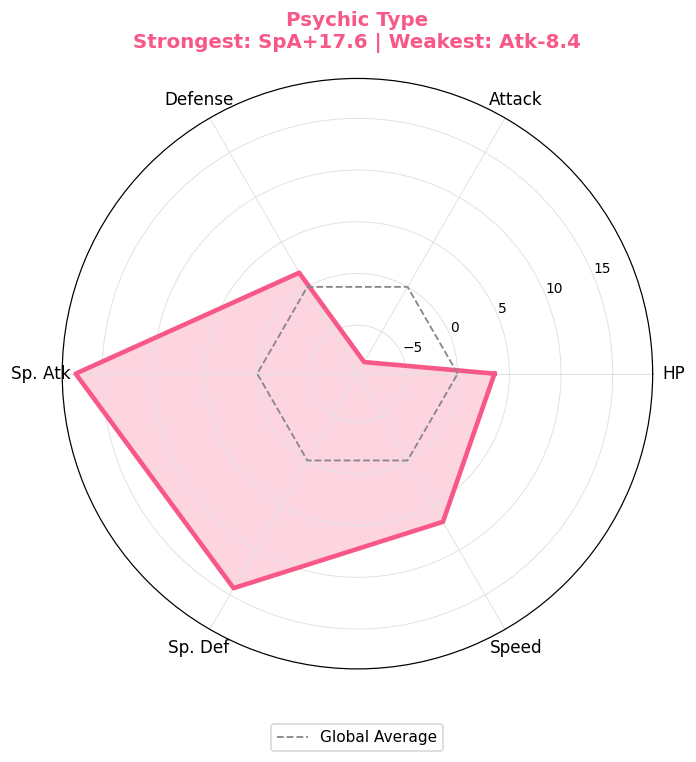

In [23]:
plot_updated_type_profile("psychic")


This code draws the updated Psychic type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.14: Bug Type Profile


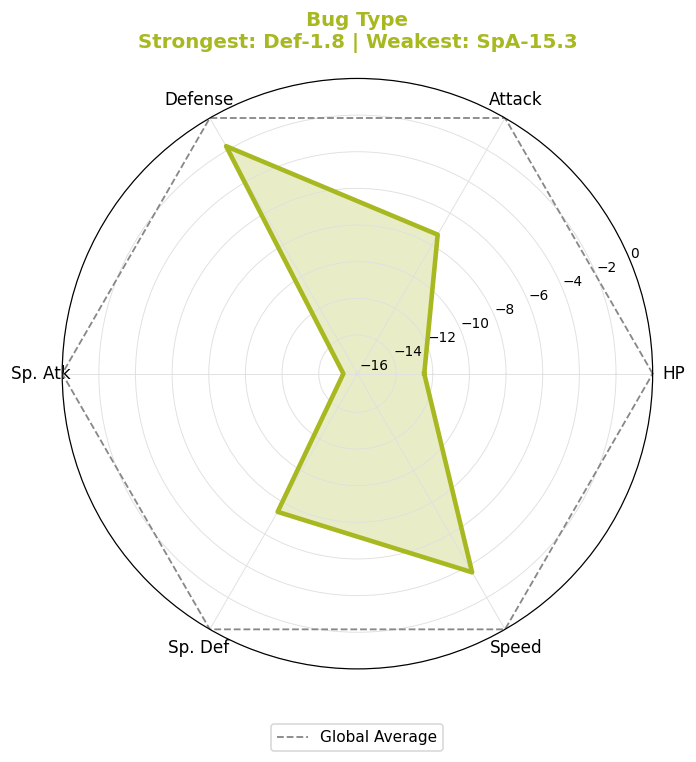

In [24]:
plot_updated_type_profile("bug")


This code draws the updated Bug type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.15: Rock Type Profile


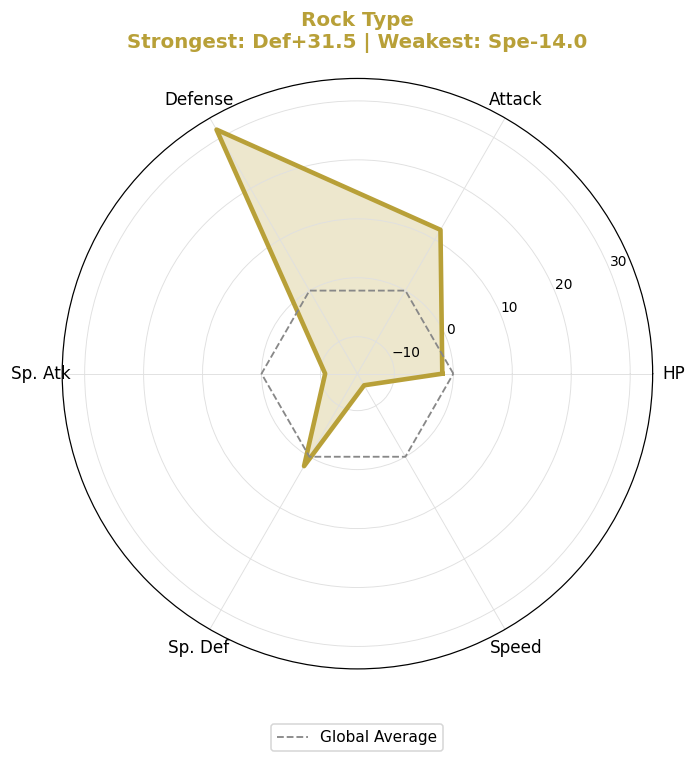

In [25]:
plot_updated_type_profile("rock")


This code draws the updated Rock type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.16: Ghost Type Profile


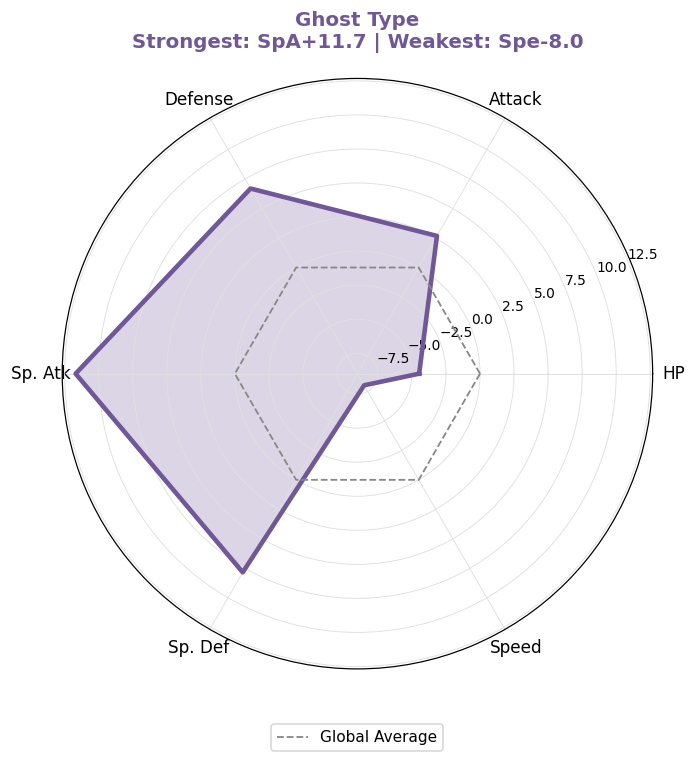

In [26]:
plot_updated_type_profile("ghost")


This code draws the updated Ghost type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.17: Dragon Type Profile


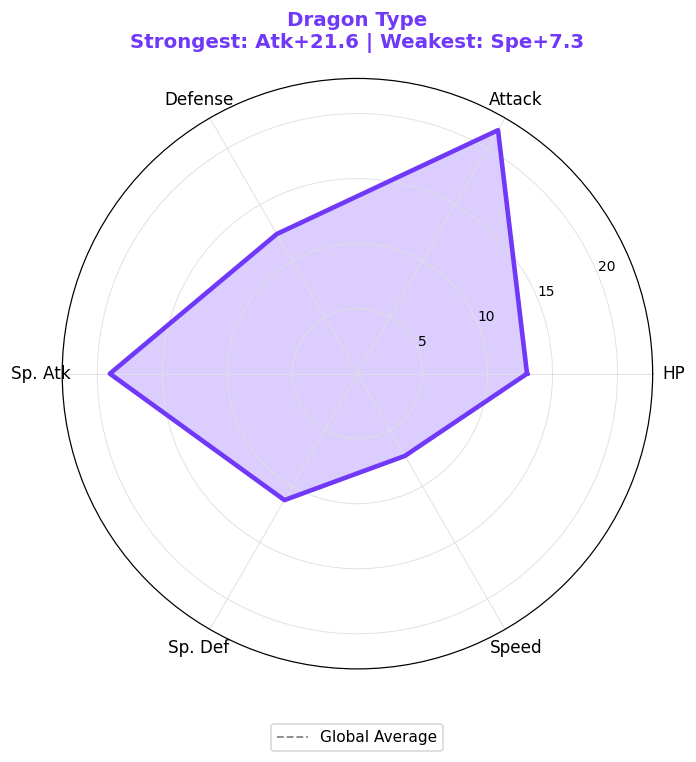

In [27]:
plot_updated_type_profile("dragon")


This code draws the updated Dragon type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.18: Dark Type Profile


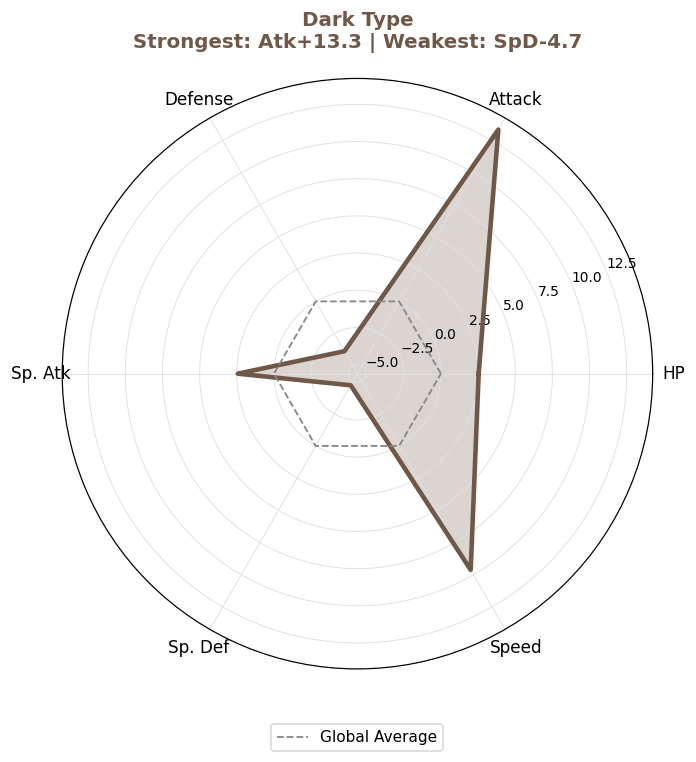

In [28]:
plot_updated_type_profile("dark")


This code draws the updated Dark type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.19: Steel Type Profile


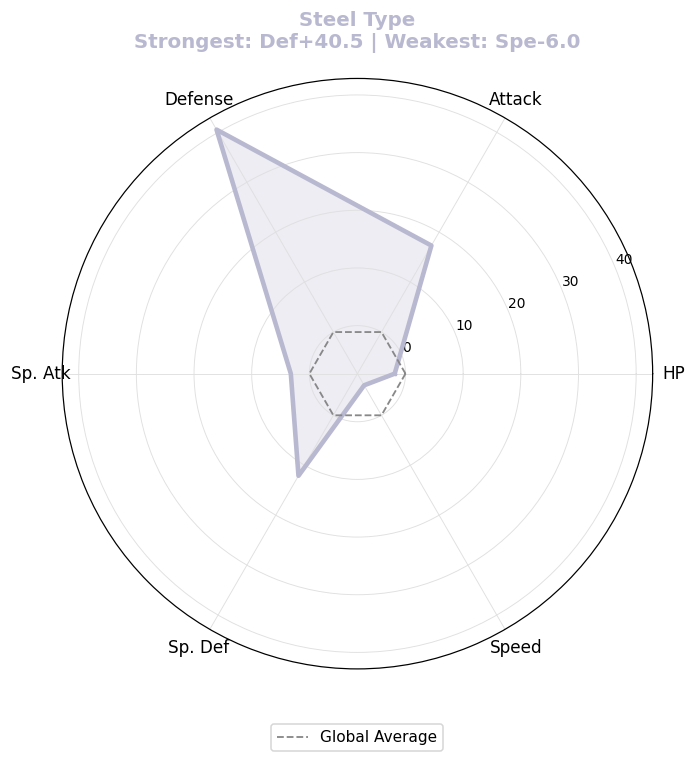

In [29]:
plot_updated_type_profile("steel")


This code draws the updated Steel type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


### Figure 2.20: Fairy Type Profile


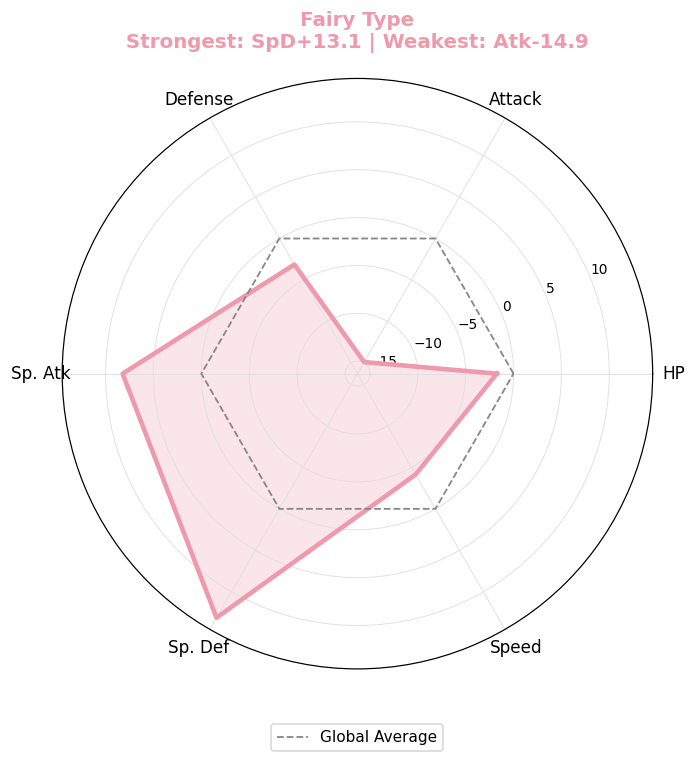

In [30]:
plot_updated_type_profile("fairy")


This code draws the updated Fairy type radar profile from the new project script. The figure highlights the type's strongest and weakest stat deviations relative to the global average.


## PART3 Exploratory Analysis of Pokémon Capture Difficulty

This section creates a capture difficulty coefficient from capture rate values. Lower capture rates are treated as harder to catch, so the coefficient is scaled from 0 for easiest to 1 for hardest.


In [31]:
capture_df = df.copy()
capture_df["capture_rate_num"] = capture_df["capture_rate"].apply(parse_capture_rate)

min_rate = capture_df["capture_rate_num"].min()
max_rate = capture_df["capture_rate_num"].max()

if max_rate == min_rate:
    capture_df["capture_difficulty_coef"] = 0.0
else:
    capture_df["capture_difficulty_coef"] = (max_rate - capture_df["capture_rate_num"]) / (max_rate - min_rate)

capture_df["type2_cleaned"] = normalize_type2(capture_df["type2"])
capture_df["legendary_label"] = capture_df["is_legendary"].map({0: "Non-Legendary", 1: "Legendary"})

top_hardest = (
    capture_df[["name", "type1", "type2_cleaned", "generation", "is_legendary", "capture_rate_num", "capture_difficulty_coef", "base_total"]]
    .sort_values(by=["capture_difficulty_coef", "base_total"], ascending=[False, False])
    .head(15)
)

top_easiest = (
    capture_df[["name", "type1", "type2_cleaned", "generation", "is_legendary", "capture_rate_num", "capture_difficulty_coef", "base_total"]]
    .sort_values(by=["capture_difficulty_coef", "base_total"], ascending=[True, True])
    .head(15)
)

type_difficulty = (
    capture_df.groupby("type1")
    .agg(avg_difficulty=("capture_difficulty_coef", "mean"), avg_capture_rate=("capture_rate_num", "mean"), count=("name", "count"))
    .reset_index()
    .sort_values("avg_difficulty", ascending=False)
)

generation_difficulty = (
    capture_df.groupby("generation")
    .agg(avg_difficulty=("capture_difficulty_coef", "mean"), avg_capture_rate=("capture_rate_num", "mean"), count=("name", "count"))
    .reset_index()
)

legendary_summary = (
    capture_df.groupby("legendary_label")
    .agg(avg_difficulty=("capture_difficulty_coef", "mean"), avg_capture_rate=("capture_rate_num", "mean"), count=("name", "count"))
    .reset_index()
)

print("Capture rate range:", min_rate, "to", max_rate)
print("Capture difficulty summary:")
display(capture_df["capture_difficulty_coef"].describe().to_frame())
print("Top hardest Pokemon:")
display(top_hardest)
print("Top easiest Pokemon:")
display(top_easiest)


Capture rate range: 3 to 255
Capture difficulty summary:


,capture_difficulty_coef
count,801.000000
mean,0.620336
std,0.302575
min,0.000000
25%,0.337302
50%,0.773810
75%,0.833333
max,1.000000


Top hardest Pokemon:


,name,type1,type2_cleaned,generation,is_legendary,capture_rate_num,capture_difficulty_coef,base_total
149,Mewtwo,psychic,None,1,1,3,1.0,780
381,Kyogre,water,None,3,1,3,1.0,770
382,Groudon,ground,None,3,1,3,1.0,770
492,Arceus,normal,None,4,1,3,1.0,720
717,Zygarde,dragon,ground,6,1,3,1.0,708
375,Metagross,steel,psychic,3,0,3,1.0,700
379,Latias,dragon,psychic,3,1,3,1.0,700
380,Latios,dragon,psychic,3,1,3,1.0,700
645,Kyurem,dragon,ice,5,1,3,1.0,700
718,Diancie,rock,fairy,6,1,3,1.0,700


Top easiest Pokemon:


,name,type1,type2_cleaned,generation,is_legendary,capture_rate_num,capture_difficulty_coef,base_total
400,Kricketot,bug,None,4,0,255,0.0,194
9,Caterpie,bug,None,1,0,255,0.0,195
12,Weedle,bug,poison,1,0,255,0.0,195
264,Wurmple,bug,None,3,0,255,0.0,195
128,Magikarp,water,None,1,0,255,0.0,200
348,Feebas,water,None,3,0,255,0.0,200
663,Scatterbug,bug,None,6,0,255,0.0,200
193,Wooper,water,ground,2,0,255,0.0,210
160,Sentret,normal,None,2,0,255,0.0,215
260,Poochyena,dark,None,3,0,255,0.0,220


### Figure 3.1: Distribution of Capture Difficulty


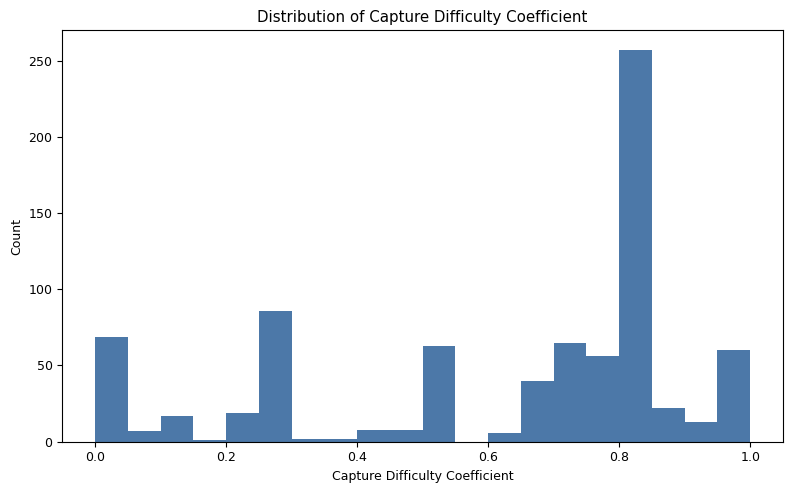

In [32]:
plt.figure(figsize=(8, 5))
plt.hist(capture_df["capture_difficulty_coef"].dropna(), bins=20, color="#4C78A8")
plt.title("Distribution of Capture Difficulty Coefficient")
plt.xlabel("Capture Difficulty Coefficient")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
plt.close()


This code plots the distribution of the capture difficulty coefficient. The histogram shows whether Pokemon are mostly easy to catch, hard to catch, or spread across the full difficulty scale.


### Figure 3.2: Average Capture Difficulty by Primary Type


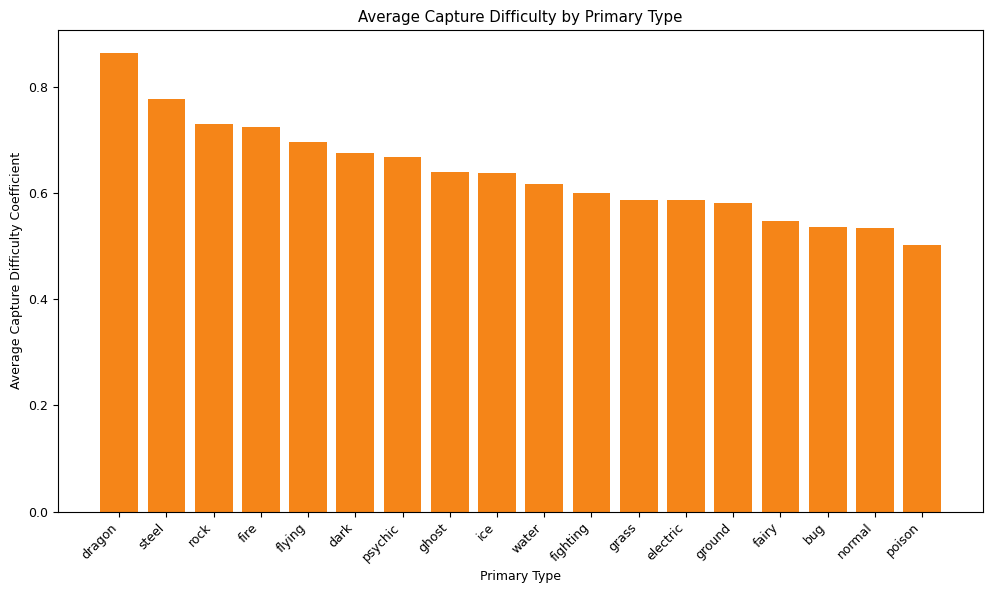

In [33]:
plt.figure(figsize=(10, 6))
plt.bar(type_difficulty["type1"], type_difficulty["avg_difficulty"], color="#F58518")
plt.title("Average Capture Difficulty by Primary Type")
plt.xlabel("Primary Type")
plt.ylabel("Average Capture Difficulty Coefficient")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
plt.close()


This code averages capture difficulty by primary type and visualizes the result as a bar chart. The figure helps compare which types are generally harder or easier to catch.


### Figure 3.3: Capture Difficulty vs Base Total


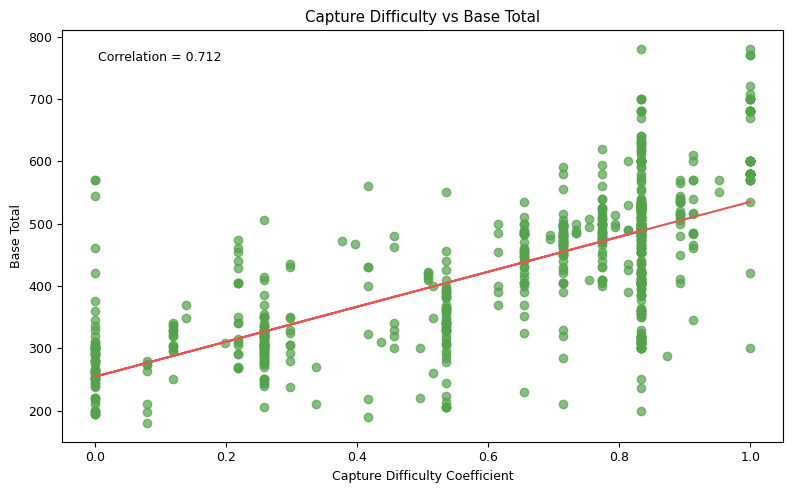

In [34]:
plot_df = capture_df[["capture_difficulty_coef", "base_total"]].dropna()
x = plot_df["capture_difficulty_coef"]
y = plot_df["base_total"]

slope, intercept = np.polyfit(x, y, 1)
regression_line = slope * x + intercept
correlation = x.corr(y)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7, color="#54A24B")
plt.plot(x, regression_line, color="#E45756")
plt.title("Capture Difficulty vs Base Total")
plt.xlabel("Capture Difficulty Coefficient")
plt.ylabel("Base Total")
plt.text(0.05, 0.95, f"Correlation = {correlation:.3f}", transform=plt.gca().transAxes, verticalalignment="top")
plt.tight_layout()
plt.show()
plt.close()


This code compares capture difficulty with base stat total and adds a fitted trend line. The figure shows whether stronger Pokemon tend to have higher capture difficulty.


### Figure 3.4: Capture Difficulty by Legendary Status


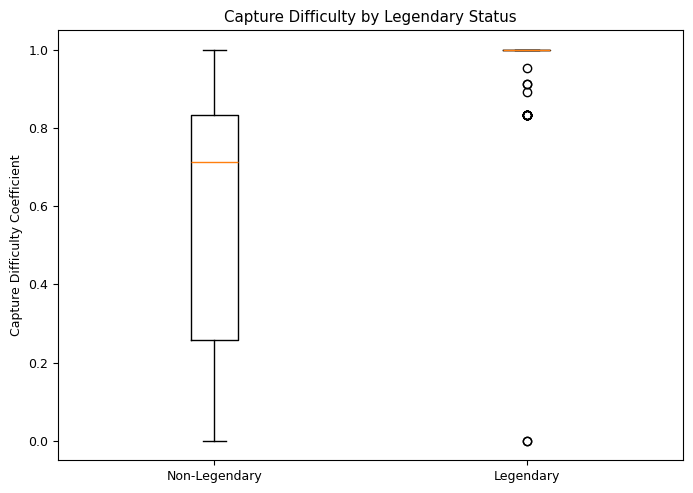

In [35]:
non_legendary = capture_df.loc[capture_df["is_legendary"] == 0, "capture_difficulty_coef"].dropna()
legendary = capture_df.loc[capture_df["is_legendary"] == 1, "capture_difficulty_coef"].dropna()

plt.figure(figsize=(7, 5))
plt.boxplot([non_legendary, legendary], tick_labels=["Non-Legendary", "Legendary"])
plt.title("Capture Difficulty by Legendary Status")
plt.ylabel("Capture Difficulty Coefficient")
plt.tight_layout()
plt.show()
plt.close()


This code compares the capture difficulty distributions for legendary and non-legendary Pokemon. The boxplot shows whether legendary Pokemon are generally harder to catch.


### Figure 3.5: Average Capture Difficulty by Generation


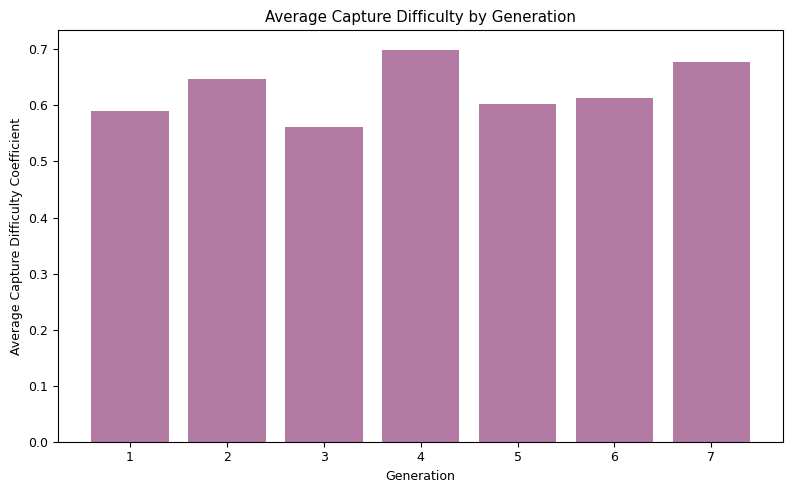

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(generation_difficulty["generation"].astype(str), generation_difficulty["avg_difficulty"], color="#B279A2")
plt.title("Average Capture Difficulty by Generation")
plt.xlabel("Generation")
plt.ylabel("Average Capture Difficulty Coefficient")
plt.tight_layout()
plt.show()
plt.close()


This code calculates average capture difficulty for each generation. The figure shows whether later or earlier generations tend to contain harder-to-catch Pokemon.


### Figure 3.6: Top 15 Hardest Pokemon


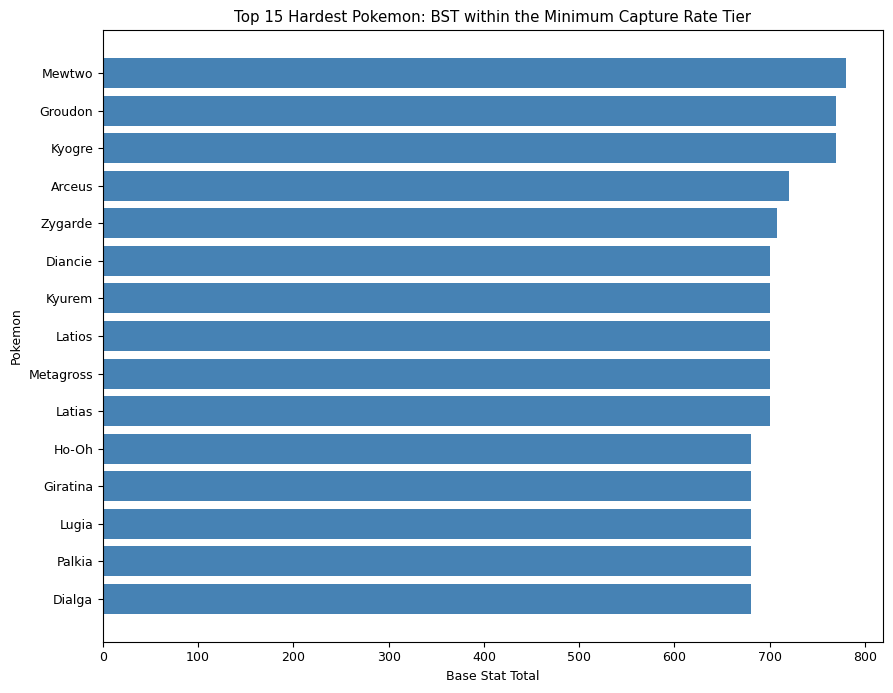

In [37]:
top_hardest_plot = top_hardest.sort_values("base_total", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(top_hardest_plot["name"], top_hardest_plot["base_total"], color="steelblue")
plt.title("Top 15 Hardest Pokemon: BST within the Minimum Capture Rate Tier")
plt.xlabel("Base Stat Total")
plt.ylabel("Pokemon")
plt.tight_layout()
plt.show()
plt.close()


This code displays the hardest-to-catch Pokemon and uses base stat total to separate Pokemon with the same minimum capture rate. The chart shows which very hard-to-catch Pokemon are also strongest by BST.


### Figure 3.7: Top 15 Easiest Pokemon


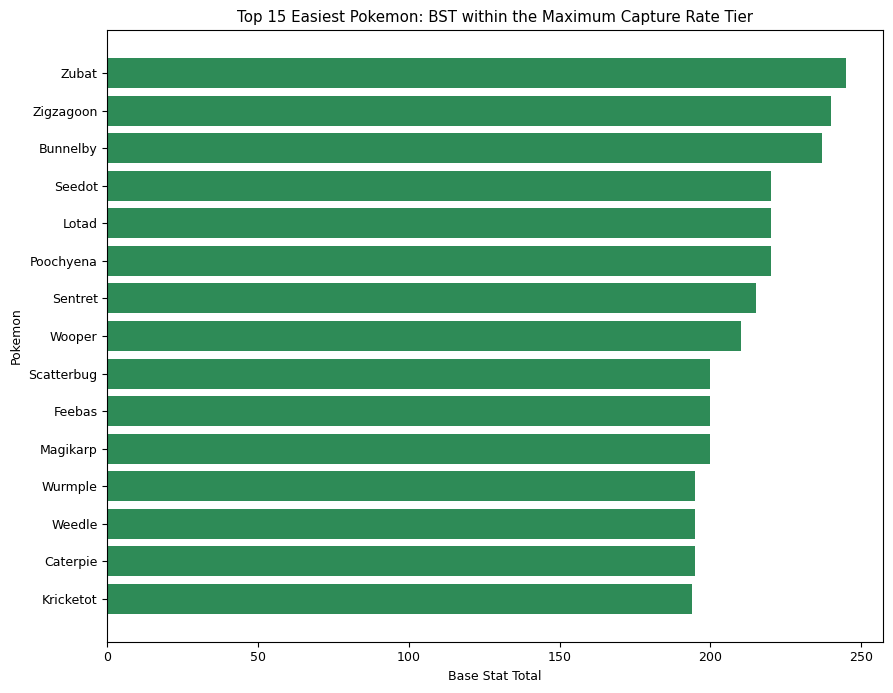

In [38]:
top_easiest_plot = top_easiest.sort_values("base_total", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(top_easiest_plot["name"], top_easiest_plot["base_total"], color="seagreen")
plt.title("Top 15 Easiest Pokemon: BST within the Maximum Capture Rate Tier")
plt.xlabel("Base Stat Total")
plt.ylabel("Pokemon")
plt.tight_layout()
plt.show()
plt.close()


This code displays the easiest-to-catch Pokemon and uses base stat total to distinguish Pokemon with the same maximum capture rate. The chart shows how strong the easiest Pokemon are within that tier.


## Part4 Machine Learning

This section builds a logistic-regression-style classifier with `SGDClassifier` to predict whether a Pokemon is legendary. It keeps the original modeling idea while using the shared cleaned dataset loaded at the start.


### Figure 4.1: Class Distribution of Legendary Status


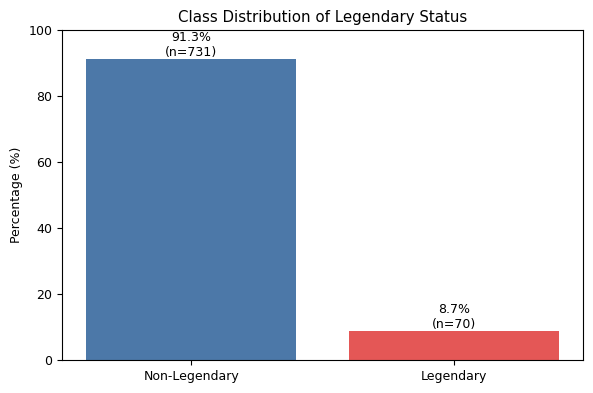

In [39]:
class_counts = df["is_legendary"].value_counts().sort_index().reindex([0, 1], fill_value=0)
class_percent = df["is_legendary"].value_counts(normalize=True).sort_index().reindex([0, 1], fill_value=0) * 100

plt.figure(figsize=(6, 4))
plt.bar(["Non-Legendary", "Legendary"], class_percent.values, color=["#4C78A8", "#E45756"])
plt.ylabel("Percentage (%)")
plt.title("Class Distribution of Legendary Status")

for i, value in enumerate(class_percent.values):
    count = class_counts.values[i]
    plt.text(i, value + 1, f"{value:.1f}%\n(n={count})", ha="center")

plt.ylim(0, 100)
plt.tight_layout()
plt.show()
plt.close()


This code calculates the percentage of legendary and non-legendary Pokemon. The figure shows the strong class imbalance that the classification model needs to handle.


In [40]:
model_vars = [
    "name", "is_legendary", "type1", "generation", "height_m", "weight_kg",
    "capture_rate", "base_egg_steps", "experience_growth", "hp", "attack",
    "defense", "sp_attack", "sp_defense", "speed",
]

missing_model_vars = [column for column in model_vars if column not in df.columns]
if missing_model_vars:
    raise ValueError(f"Missing columns required for modeling: {missing_model_vars}")

pokemon_model = df[model_vars].copy()

numeric_features = [
    "height_m", "weight_kg", "capture_rate", "base_egg_steps", "experience_growth",
    "hp", "attack", "defense", "sp_attack", "sp_defense", "speed",
]
categorical_features = ["type1", "generation"]

for col in numeric_features:
    if col == "capture_rate":
        pokemon_model[col] = pokemon_model[col].apply(parse_capture_rate)
    pokemon_model[col] = pd.to_numeric(pokemon_model[col], errors="coerce")

pokemon_model["generation"] = pokemon_model["generation"].astype(str)
pokemon_model = pokemon_model.dropna().copy()

X = pokemon_model[numeric_features + categorical_features]
y = pokemon_model["is_legendary"]
pokemon_names = pokemon_model["name"]

X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X,
    y,
    pokemon_names,
    test_size=0.30,
    random_state=123,
    stratify=y,
)

print("Dataset used for modeling:", pokemon_model.shape)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("Training class distribution:")
display(y_train.value_counts().sort_index().to_frame("count"))
print("Testing class distribution:")
display(y_test.value_counts().sort_index().to_frame("count"))


Dataset used for modeling: (801, 15)
Training set size: 560
Testing set size: 241
Training class distribution:


,count
is_legendary,
0,511
1,49


Testing class distribution:


,count
is_legendary,
0,220
1,21


### Figure 4.2: Train-Test Split


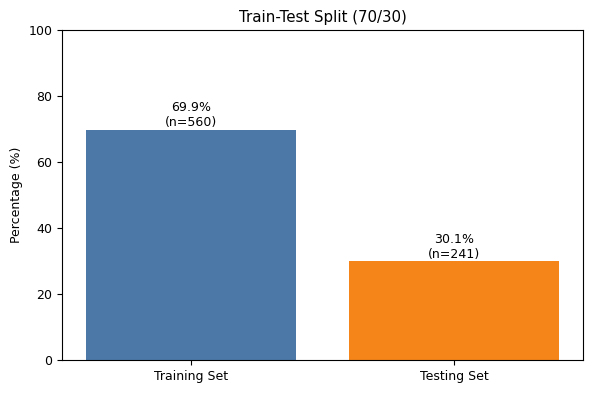

In [41]:
train_size = X_train.shape[0]
test_size = X_test.shape[0]
total_size = train_size + test_size

split_percentages = [train_size / total_size * 100, test_size / total_size * 100]
split_counts = [train_size, test_size]

plt.figure(figsize=(6, 4))
plt.bar(["Training Set", "Testing Set"], split_percentages, color=["#4C78A8", "#F58518"])
plt.ylabel("Percentage (%)")
plt.title("Train-Test Split (70/30)")

for i, value in enumerate(split_percentages):
    plt.text(i, value + 1, f"{value:.1f}%\n(n={split_counts[i]})", ha="center")

plt.ylim(0, 100)
plt.tight_layout()
plt.show()
plt.close()


This code visualizes the 70/30 train-test split used for modeling. The figure confirms how much data is used for training and how much is held out for testing.


### Figure 4.3: Class Distribution in Training and Testing Sets


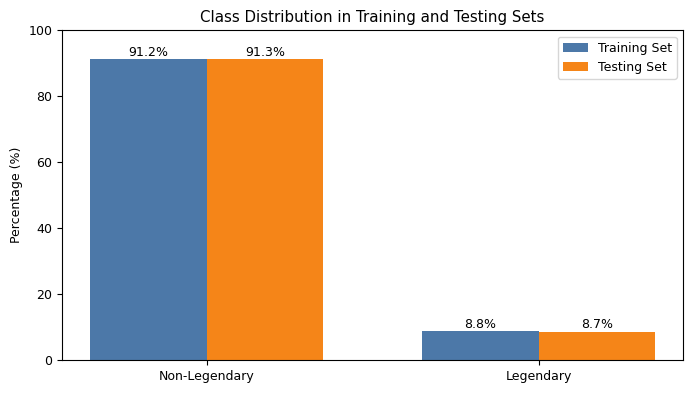

In [42]:
train_class_percent = y_train.value_counts(normalize=True).sort_index().reindex([0, 1], fill_value=0) * 100
test_class_percent = y_test.value_counts(normalize=True).sort_index().reindex([0, 1], fill_value=0) * 100

labels = ["Non-Legendary", "Legendary"]
x_pos = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x_pos - width / 2, train_class_percent.values, width, label="Training Set", color="#4C78A8")
plt.bar(x_pos + width / 2, test_class_percent.values, width, label="Testing Set", color="#F58518")

plt.xticks(x_pos, labels)
plt.ylabel("Percentage (%)")
plt.title("Class Distribution in Training and Testing Sets")
plt.legend()

for i, value in enumerate(train_class_percent.values):
    plt.text(i - width / 2, value + 1, f"{value:.1f}%", ha="center", fontsize=9)

for i, value in enumerate(test_class_percent.values):
    plt.text(i + width / 2, value + 1, f"{value:.1f}%", ha="center", fontsize=9)

plt.ylim(0, 100)
plt.tight_layout()
plt.show()
plt.close()


This code compares legendary-class proportions in the training and testing sets. The chart verifies that stratified splitting preserved similar class balance in both sets.


In [43]:
scaler = StandardScaler()

X_train_numeric_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_numeric_scaled = scaler.transform(X_test[numeric_features])

X_train_numeric_scaled = pd.DataFrame(X_train_numeric_scaled, columns=numeric_features, index=X_train.index)
X_test_numeric_scaled = pd.DataFrame(X_test_numeric_scaled, columns=numeric_features, index=X_test.index)

X_train_categorical = pd.get_dummies(X_train[categorical_features], columns=categorical_features, drop_first=True)
X_test_categorical = pd.get_dummies(X_test[categorical_features], columns=categorical_features, drop_first=True)
X_test_categorical = X_test_categorical.reindex(columns=X_train_categorical.columns, fill_value=0)

X_train_processed = pd.concat([X_train_numeric_scaled, X_train_categorical], axis=1)
X_test_processed = pd.concat([X_test_numeric_scaled, X_test_categorical], axis=1)

log_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    max_iter=2000,
    random_state=123,
    class_weight="balanced",
)
log_model.fit(X_train_processed, y_train)

y_pred = log_model.predict(X_test_processed)
y_prob = log_model.predict_proba(X_test_processed)[:, 1]

prediction_results = pd.DataFrame({
    "Pokemon": names_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Legendary_Probability": y_prob,
}).sort_values(by="Legendary_Probability", ascending=False)

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, pos_label=1)
precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Balanced Accuracy", "Recall", "Precision"],
    "Score": [accuracy, balanced_acc, recall, precision],
})

coef_df = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Coefficient": log_model.coef_[0],
})
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["Non-Legendary", "Legendary"], zero_division=0))
print("Top 15 Pokemon by predicted legendary probability:")
display(prediction_results.head(15))
print("Top 15 model coefficients by absolute value:")
display(coef_df.head(15))


Processed training data shape: (560, 34)
Processed testing data shape: (241, 34)
Classification report:
               precision    recall  f1-score   support

Non-Legendary       1.00      1.00      1.00       220
    Legendary       0.95      1.00      0.98        21

     accuracy                           1.00       241
    macro avg       0.98      1.00      0.99       241
 weighted avg       1.00      1.00      1.00       241

Top 15 Pokemon by predicted legendary probability:


,Pokemon,Actual,Predicted,Legendary_Probability
2,Ho-Oh,1,1,1.0
14,Uxie,1,1,1.0
10,Zekrom,1,1,1.0
20,Cobalion,1,1,1.0
41,Latios,1,1,1.0
43,Kyogre,1,1,1.0
25,Landorus,1,1,1.0
18,Dialga,1,1,1.0
54,Celesteela,1,1,1.0
66,Regigigas,1,1,1.0


Top 15 model coefficients by absolute value:


,Feature,Coefficient,Abs_Coefficient
33,generation_7,39.064973,39.064973
2,capture_rate,-38.826856,38.826856
3,base_egg_steps,37.824887,37.824887
4,experience_growth,36.123825,36.123825
22,type1_normal,-24.716724,24.716724
30,generation_4,24.287355,24.287355
12,type1_dragon,-24.102474,24.102474
10,speed,23.425785,23.425785
27,type1_water,20.976901,20.976901
16,type1_fire,20.260226,20.260226


### Figure 4.4: Confusion Matrix


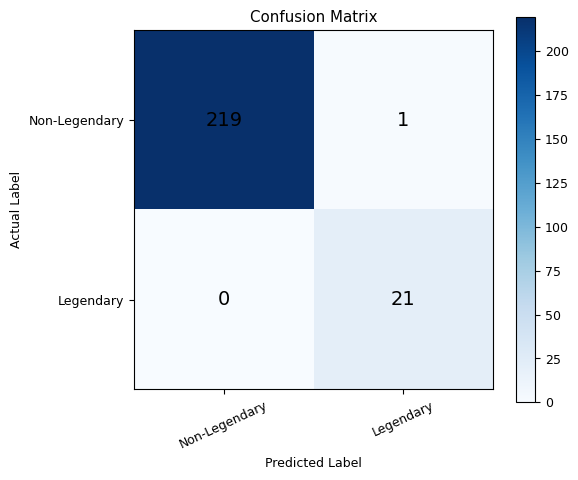

In [44]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Non-Legendary", "Legendary"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=25)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()
plt.close()


This code displays the confusion matrix for the legendary classifier. The figure shows correct and incorrect predictions for non-legendary and legendary Pokemon.


### Figure 4.5: Model Performance Metrics


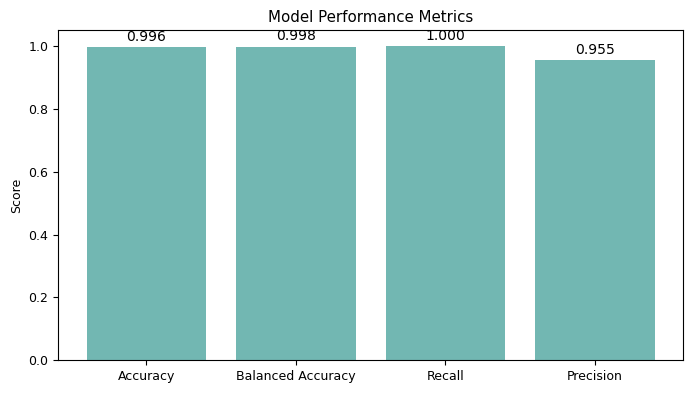

In [45]:
plt.figure(figsize=(7, 4))
plt.bar(metrics_df["Metric"], metrics_df["Score"], color="#72B7B2")
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0, 1.05)

for i, value in enumerate(metrics_df["Score"]):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()
plt.close()


This code summarizes accuracy, balanced accuracy, recall, and precision. The chart makes it easier to compare overall performance with metrics that are more sensitive to class imbalance.


### Figure 4.6: Top 15 Logistic Regression Coefficients


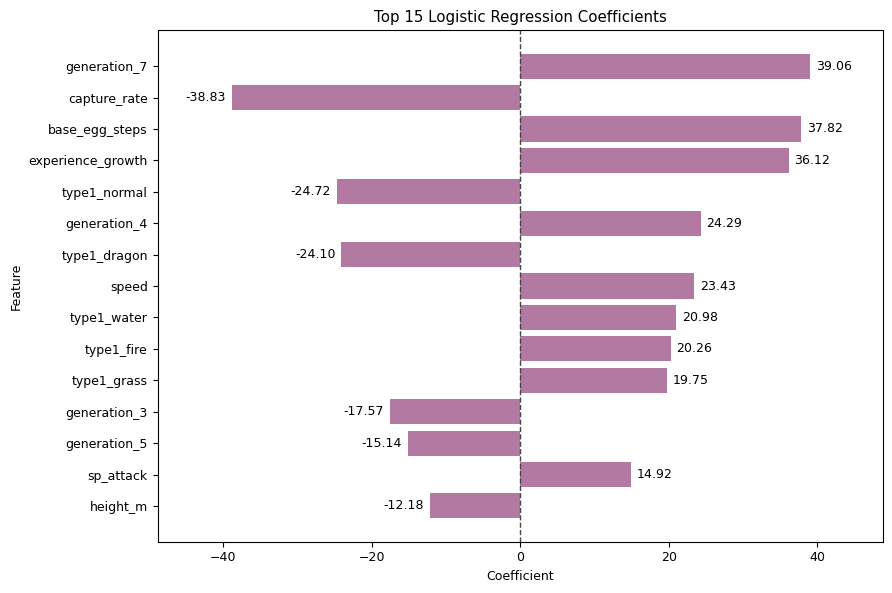

In [46]:
top_coef = coef_df.head(15).copy()
max_abs_coef = top_coef["Coefficient"].abs().max()

plt.figure(figsize=(9, 6))
plt.barh(top_coef["Feature"], top_coef["Coefficient"], color="#B279A2")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Logistic Regression Coefficients")
plt.axvline(0, linestyle="--", linewidth=1, color="#444444")

for i, value in enumerate(top_coef["Coefficient"]):
    offset = max_abs_coef * 0.02 if max_abs_coef else 0.02
    plt.text(value + offset if value > 0 else value - offset, i, f"{value:.2f}", va="center", ha="left" if value > 0 else "right", fontsize=9)

plt.xlim(-max_abs_coef * 1.25, max_abs_coef * 1.25)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
plt.close()


This code plots the model coefficients with the largest absolute values. The figure indicates which standardized numeric features or encoded categories most strongly influence the legendary prediction.


## Summary

The combined notebook now follows the updated section titles and uses `pokemon_project(1).py` as the source for the Pokémon Personality Profiles section. It still uses only `pokemon_cleaned.csv` for data loading, and each visualization remains in its own code cell followed by a short explanation.
